# NUTS Temperature Results Review

This notebook loads saved temperature-only NUTS chains from cluster runs, produces clean corner plots in the Cell-39 style, and runs posterior predictive checks against observed temperature data.

Expected files in a run directory:
- `temp_only_free4_chains.npz`
- `temp_only_free6_chains.npz`
- `temp_only_free35_chains.npz`
- `run_manifest.json` (optional but useful)

In [17]:
import sys
from pathlib import Path

# Ensure repo root is importable when running from notebooks/
REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anp_emulator import Emulator
from run_nuts_temperature import load_temperature_profiles

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
np.random.seed(42)

In [18]:
# Auto-discover latest run directory, or set RUN_DIR manually.
RUNS_BASE = REPO_ROOT / 'validation_results' / 'nuts_temperature_runs'

run_dirs = sorted([p for p in RUNS_BASE.glob('temp_nuts_*') if p.is_dir()])
print('Discovered run directories:')
for p in run_dirs:
    print(' -', p)

valid_run_dirs = [p for p in run_dirs if len(list(p.glob('temp_only_free*_chains.npz'))) > 0]
RUN_DIR = valid_run_dirs[-1] if len(valid_run_dirs) > 0 else None
print('\nSelected RUN_DIR:', RUN_DIR)

if RUN_DIR is None:
    raise FileNotFoundError(
        f'No completed run directory with chain .npz files found under {RUNS_BASE}. '
        'If jobs are still running, rerun this cell after completion.'
    )

chain_files = sorted(RUN_DIR.glob('temp_only_free*_chains.npz'))
if len(chain_files) == 0:
    raise FileNotFoundError(
        f'No chain .npz files found in {RUN_DIR}. '
        'If your cluster job is still running, rerun this cell after completion.'
    )

print('\nFound chain files:')
for f in chain_files:
    print(' -', f.name)

manifest_path = RUN_DIR / 'run_manifest.json'
if manifest_path.exists():
    with manifest_path.open('r', encoding='utf-8') as fh:
        manifest = json.load(fh)
    print('\nManifest entries:', len(manifest))
    display(pd.DataFrame(manifest)[['free_set', 'out_file', 'fit_param_names']])
else:
    manifest = None
    print('\nNo run_manifest.json found; proceeding from .npz files only.')

Discovered run directories:
 - /mnt/home/mlee1/ANP_tests/validation_results/nuts_temperature_runs/temp_nuts_20260402_143358

Selected RUN_DIR: /mnt/home/mlee1/ANP_tests/validation_results/nuts_temperature_runs/temp_nuts_20260402_143358

Found chain files:
 - temp_only_free4_chains.npz
 - temp_only_free6_chains.npz

Manifest entries: 1


,free_set,out_file,fit_param_names
0,6,validation_results/nuts_temperature_runs/temp_...,"[Omega0, sigma8, WindEnergyIn1e51erg, RadioFee..."


In [3]:
def gaussian_kernel_1d(sigma=1.2, radius=4):
    x = np.arange(-radius, radius + 1, dtype=float)
    k = np.exp(-0.5 * (x / sigma) ** 2)
    return k / np.sum(k)


def smooth_1d(y, sigma=1.1, radius=4):
    k = gaussian_kernel_1d(sigma=sigma, radius=radius)
    return np.convolve(y, k, mode='same')


def smooth_hist2d(H, sigma=1.8, radius=5):
    k = gaussian_kernel_1d(sigma=sigma, radius=radius)
    Hs = np.apply_along_axis(lambda m: np.convolve(m, k, mode='same'), axis=0, arr=H)
    Hs = np.apply_along_axis(lambda m: np.convolve(m, k, mode='same'), axis=1, arr=Hs)
    return Hs


def density_levels_from_hist(H, probs=(0.68, 0.95)):
    h = H.ravel()
    h = h[np.isfinite(h)]
    if h.size == 0 or np.all(h <= 0):
        return []
    hs = np.sort(h)[::-1]
    cs = np.cumsum(hs)
    cs = cs / cs[-1]
    levels = []
    for p in probs:
        idx = min(np.searchsorted(cs, p), hs.size - 1)
        levels.append(hs[idx])
    return sorted(set(levels))


def plot_clean_corner(flat, labels, mins, maxs, fids, title):
    nd = flat.shape[1]
    fig, axes = plt.subplots(nd, nd, figsize=(3.0 * nd, 3.0 * nd))

    for i in range(nd):
        for j in range(nd):
            ax = axes[i, j]
            if i == j:
                x = flat[:, j]
                x = x[np.isfinite(x)]
                if x.size > 5:
                    d, e = np.histogram(x, bins=26, density=True)
                    c = 0.5 * (e[:-1] + e[1:])
                    ax.plot(c, smooth_1d(d), color='black', lw=1.8)
                if np.isfinite(mins[j]):
                    ax.axvline(mins[j], color='0.7', ls=':', lw=0.9)
                if np.isfinite(maxs[j]):
                    ax.axvline(maxs[j], color='0.7', ls=':', lw=0.9)
                if np.isfinite(fids[j]):
                    ax.axvline(fids[j], color='0.35', ls='--', lw=1.0)
                if np.isfinite(mins[j]) and np.isfinite(maxs[j]):
                    ax.set_xlim(mins[j], maxs[j])

            elif i > j:
                x = flat[:, j]
                y = flat[:, i]
                m = np.isfinite(x) & np.isfinite(y)
                x, y = x[m], y[m]
                if x.size > 20:
                    H, xe, ye = np.histogram2d(x, y, bins=64, density=True)
                    Hs = smooth_hist2d(H)
                    xc = 0.5 * (xe[:-1] + xe[1:])
                    yc = 0.5 * (ye[:-1] + ye[1:])
                    levels = density_levels_from_hist(Hs, probs=(0.68, 0.95))
                    if len(levels) > 0:
                        ax.contour(xc, yc, Hs.T, levels=levels, colors=['black'] * len(levels), linewidths=1.1)

                if np.isfinite(mins[j]):
                    ax.axvline(mins[j], color='0.75', ls=':', lw=0.7)
                if np.isfinite(maxs[j]):
                    ax.axvline(maxs[j], color='0.75', ls=':', lw=0.7)
                if np.isfinite(mins[i]):
                    ax.axhline(mins[i], color='0.75', ls=':', lw=0.7)
                if np.isfinite(maxs[i]):
                    ax.axhline(maxs[i], color='0.75', ls=':', lw=0.7)
                if np.isfinite(fids[j]):
                    ax.axvline(fids[j], color='0.35', ls='--', lw=0.75)
                if np.isfinite(fids[i]):
                    ax.axhline(fids[i], color='0.35', ls='--', lw=0.75)

                if np.isfinite(mins[j]) and np.isfinite(maxs[j]):
                    ax.set_xlim(mins[j], maxs[j])
                if np.isfinite(mins[i]) and np.isfinite(maxs[i]):
                    ax.set_ylim(mins[i], maxs[i])

            else:
                ax.axis('off')
                continue

            if i == nd - 1:
                ax.set_xlabel(labels[j], fontsize=8)
            else:
                ax.set_xticklabels([])

            if j == 0 and i > 0:
                ax.set_ylabel(labels[i], fontsize=8)
            elif j > 0:
                ax.set_yticklabels([])

    plt.suptitle(title, y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

In [19]:
# Load observed profiles using the same preprocessing as the run script.
# For diagnostics, default radial binning is matched to training if we can infer it.
sample_npz = np.load(chain_files[0], allow_pickle=True)

kt_dir = Path(str(sample_npz['kt_dir'].item())) if 'kt_dir' in sample_npz else Path('/mnt/home/mlee1/CPGP_xray/Data/data/kT')
catalog_path = Path(str(sample_npz['catalog_path'].item())) if 'catalog_path' in sample_npz else Path('/mnt/home/mlee1/CPGP_xray/Data/clusters.txt')
sigma_floor_frac_temp = 0.25
if 'sigma_floor_frac_temp' in sample_npz:
    sigma_floor_frac_temp = float(sample_npz['sigma_floor_frac_temp'])

run_dir_meta = str(sample_npz['run_dir'].item()) if 'run_dir' in sample_npz else 'anp_training_runs/anp_all_profiles_20260325_175639'
run_dir_path = Path(run_dir_meta)
if not run_dir_path.is_absolute():
    run_dir_path = (REPO_ROOT / run_dir_path).resolve()

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
emu = Emulator.from_run_dir(run_dir_path, device=device)

# Track chain sampling grid if available; older files may not store this key.
RR500_NBIN_CHAIN = int(sample_npz['rr500_nbin']) if 'rr500_nbin' in sample_npz else 24
RR500_NBIN_OVERRIDE = None  # set an int (for example 24 or 30) to force a grid manually
RR500_NBIN_TRAIN = None

try:
    from train_anp_emulator import discover_runs, resolve_profile_file

    train_args_meta = dict(getattr(emu, 'args', {}))
    radial_stride_meta = int(train_args_meta.get('radial_stride', 1))

    # If n_r is not explicitly stored in checkpoint args, infer it from one training profile file.
    for key in ('n_r', 'num_r_bins', 'n_radial_bins'):
        if key in train_args_meta and train_args_meta[key] is not None:
            RR500_NBIN_TRAIN = int(train_args_meta[key])
            break

    if RR500_NBIN_TRAIN is None:
        profiles_base = Path(str(train_args_meta.get('profiles_base', '/mnt/home/mlee1/ceph/Profiles_cy')))
        suite = str(train_args_meta.get('suite', 'IllustrisTNG'))
        sim_set = str(train_args_meta.get('sim_set', 'SB35'))
        snapnums = list(train_args_meta.get('resolved_snapnums', [train_args_meta.get('snapnum', 90)]))
        snap_for_scan = int(snapnums[0]) if len(snapnums) > 0 else 90

        runs_scan = discover_runs(profiles_base, suite=suite, sim_set=sim_set, snapnum=snap_for_scan)
        if len(runs_scan) > 0:
            fp_train = resolve_profile_file(
                runs_scan[0],
                base_path=profiles_base,
                suite=suite,
                sim_set=sim_set,
                snapnum=snap_for_scan,
            )
            with np.load(fp_train) as z:
                r_train = z['radial_bins'].astype(np.float32)
            RR500_NBIN_TRAIN = int(r_train[::max(radial_stride_meta, 1)].shape[0])
except Exception as exc:
    print(f'Could not infer training radial bin count automatically: {exc}')

if RR500_NBIN_OVERRIDE is not None:
    rr500_nbin = int(RR500_NBIN_OVERRIDE)
elif RR500_NBIN_TRAIN is not None:
    rr500_nbin = int(RR500_NBIN_TRAIN)
else:
    rr500_nbin = int(RR500_NBIN_CHAIN)

obs = load_temperature_profiles(
    kt_dir=kt_dir,
    catalog_path=catalog_path,
    rr500_nbin=rr500_nbin,
    sigma_floor_frac=sigma_floor_frac_temp,
)

RR500_NBIN_EVAL = int(rr500_nbin)

print('Loaded emulator from:', run_dir_path)
print('Emulator device:', emu.device)
print('Observed halos:', len(obs.names))
print(f'Radial bins -> chain: {RR500_NBIN_CHAIN}, training: {RR500_NBIN_TRAIN}, evaluation: {RR500_NBIN_EVAL}')

if RR500_NBIN_EVAL != RR500_NBIN_CHAIN:
    print(
        'NOTE: Posterior chains were sampled with a different rr500_nbin. '
        'This notebook is re-evaluating those posterior draws on the training-matched grid for diagnostics. '
        'For strict apples-to-apples likelihood comparison, rerun NUTS with the same rr500_nbin.'
    )

Loaded 54 matched halos from /mnt/home/mlee1/CPGP_xray/Data/data/kT
Missing catalog matches: 2
Median valid bins per halo: 17.5
Loaded emulator from: /mnt/home/mlee1/ANP_tests/anp_training_runs/anp_all_profiles_20260325_175639
Emulator device: cuda
Observed halos: 54
Radial bins -> chain: 24, training: 30, evaluation: 30
NOTE: Posterior chains were sampled with a different rr500_nbin. This notebook is re-evaluating those posterior draws on the training-matched grid for diagnostics. For strict apples-to-apples likelihood comparison, rerun NUTS with the same rr500_nbin.


In [20]:
# Build a dictionary keyed by free-set label from chain filenames.
chains_by_key = {}
for fp in chain_files:
    name = fp.name
    if 'free4' in name:
        key = '4'
    elif 'free6' in name:
        key = '6'
    elif 'free35' in name:
        key = '35'
    else:
        continue
    chains_by_key[key] = np.load(fp, allow_pickle=True)

print('Loaded chain sets:', sorted(chains_by_key.keys()))

rows = []
for k, z in sorted(chains_by_key.items(), key=lambda t: int(t[0])):
    s = z['samples']
    rows.append({
        'free_set': k,
        'n_chains': int(s.shape[0]),
        'draws_per_chain': int(s.shape[1]),
        'theta_dim': int(s.shape[2]),
        'fit_idxs': [int(x) for x in z['fit_idxs']],
        'fit_names': [str(x) for x in z['fit_param_names']],
    })
display(pd.DataFrame(rows))

Loaded chain sets: ['4', '6']


,free_set,n_chains,draws_per_chain,theta_dim,fit_idxs,fit_names
0,4,4,6000,35,"[2, 3, 4, 5]","[WindEnergyIn1e51erg, RadioFeedbackFactor, Var..."
1,6,4,6000,35,"[0, 1, 2, 3, 4, 5]","[Omega0, sigma8, WindEnergyIn1e51erg, RadioFee..."


In [6]:
# Cell-39-style ASN/AAGN corner plot helper
plot_specs = [
    {'raw_name': 'WindEnergyIn1e51erg', 'plot_name': 'ASN1', 'scale': 3.6, 'log_flag': True},
    {'raw_name': 'RadioFeedbackFactor', 'plot_name': 'AAGN1', 'scale': 1.0, 'log_flag': True},
    {'raw_name': 'VariableWindVelFactor', 'plot_name': 'ASN2', 'scale': 3.7, 'log_flag': True},
    {'raw_name': 'RadioFeedbackReiorientationFactor', 'plot_name': 'AAGN2', 'scale': 20.0, 'log_flag': True},
]

def corner_asn_aagn(npz_obj, max_points=12000):
    theta_cols = [str(x) for x in npz_obj['theta_cols']]
    theta_fid = np.asarray(npz_obj['theta_fid'], dtype=float)
    prior_lo = np.asarray(npz_obj['prior_lo_run'], dtype=float)
    prior_hi = np.asarray(npz_obj['prior_hi_run'], dtype=float)
    samples = np.asarray(npz_obj['samples'], dtype=float)

    flat = samples.reshape(-1, samples.shape[-1])
    if flat.shape[0] > max_points:
        ii = np.random.choice(flat.shape[0], size=max_points, replace=False)
        flat = flat[ii]

    vals, labels, mins, maxs, fids = [], [], [], [], []
    for spec in plot_specs:
        if spec['raw_name'] not in theta_cols:
            continue
        j = theta_cols.index(spec['raw_name'])

        x = flat[:, j] / spec['scale']
        lo = prior_lo[j] / spec['scale']
        hi = prior_hi[j] / spec['scale']
        fd = theta_fid[j] / spec['scale']

        if spec['log_flag']:
            x = np.log10(np.clip(x, 1e-300, None))
            lo = np.log10(max(lo, 1e-300))
            hi = np.log10(max(hi, 1e-300))
            fd = np.log10(max(fd, 1e-300))
            label = f"log10({spec['plot_name']})"
        else:
            label = spec['plot_name']

        vals.append(x)
        mins.append(lo)
        maxs.append(hi)
        fids.append(fd)
        labels.append(label)

    if len(vals) == 0:
        raise RuntimeError('None of the ASN/AAGN plotting parameters are present in this fit.')

    flat_plot = np.column_stack(vals)
    mins = np.asarray(mins, dtype=float)
    maxs = np.asarray(maxs, dtype=float)
    fids = np.asarray(fids, dtype=float)

    fit_count = len(npz_obj['fit_idxs'])
    plot_clean_corner(
        flat_plot, labels, mins, maxs, fids,
        title=f'Pyro NUTS Corner in ASN/AAGN Variables (free {fit_count} params)'
    )

Corner plot for free-set 4


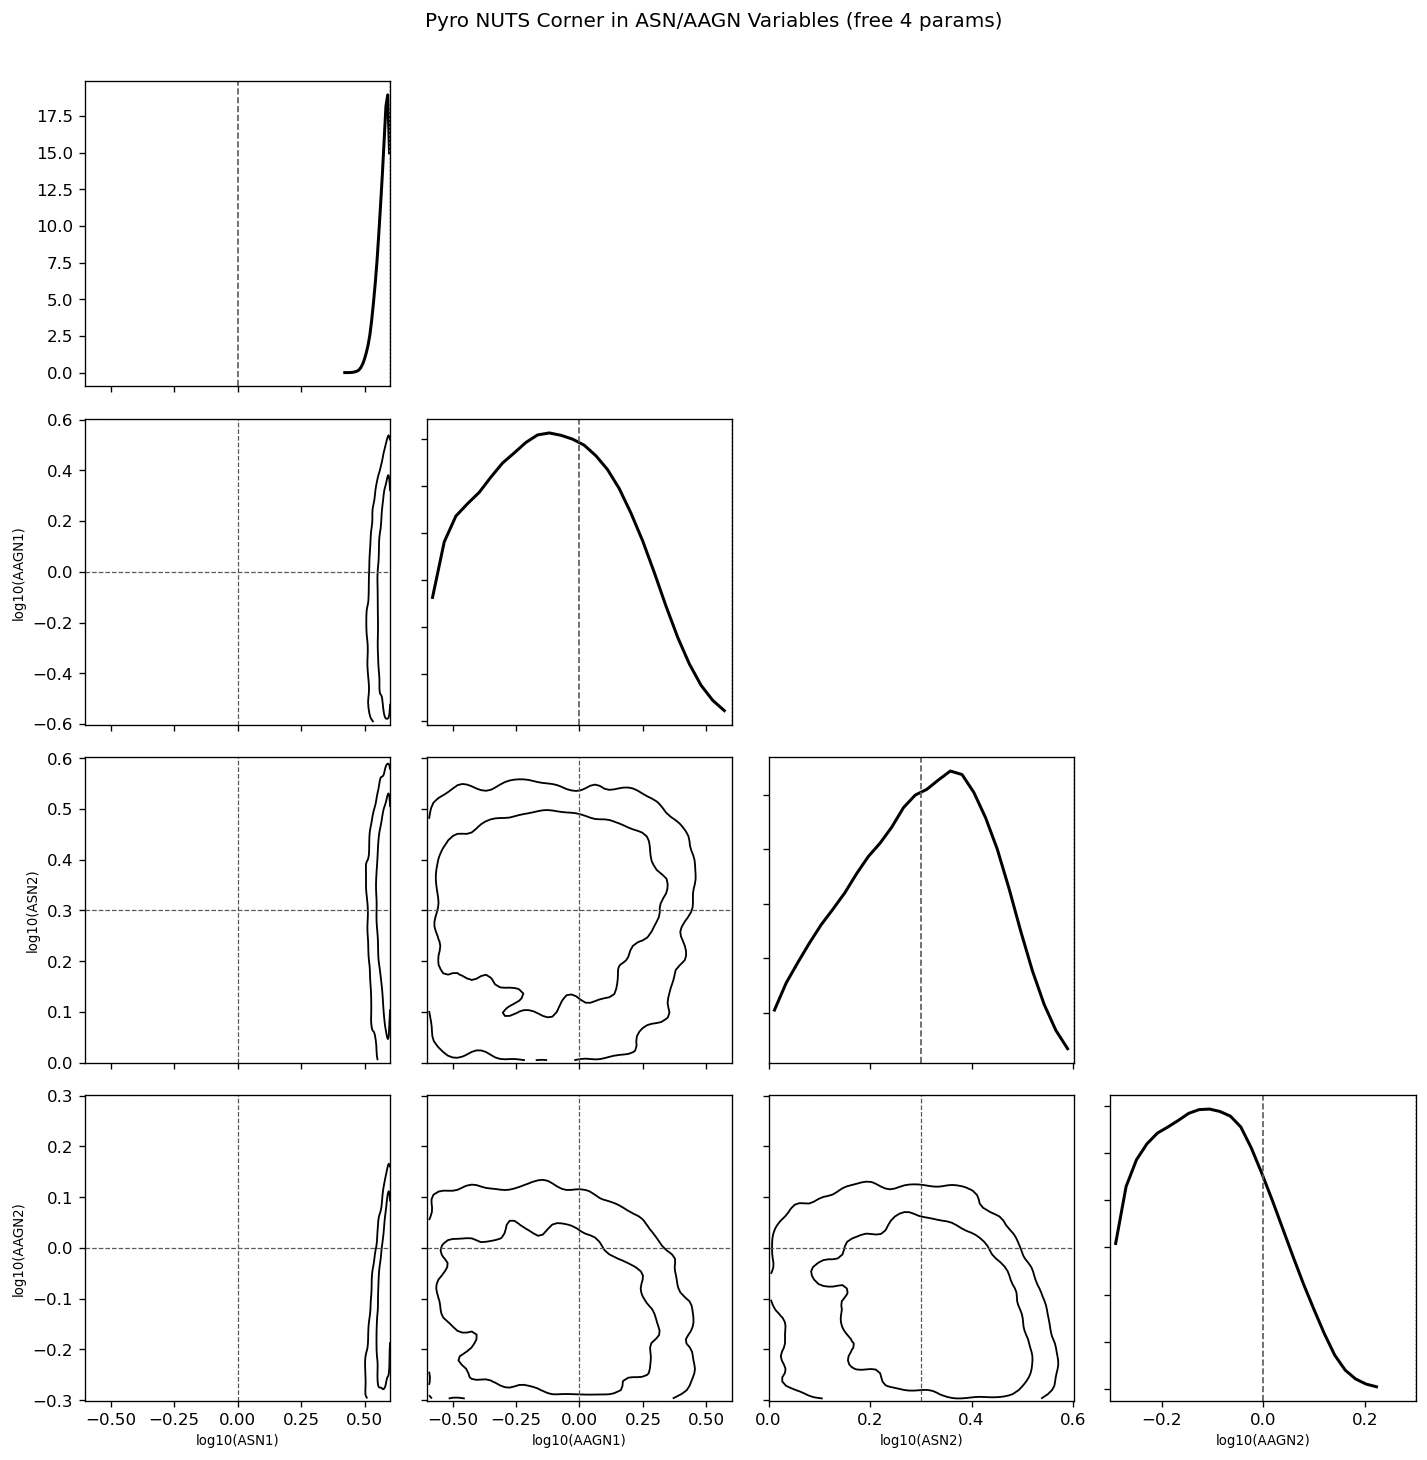

Corner plot for free-set 6


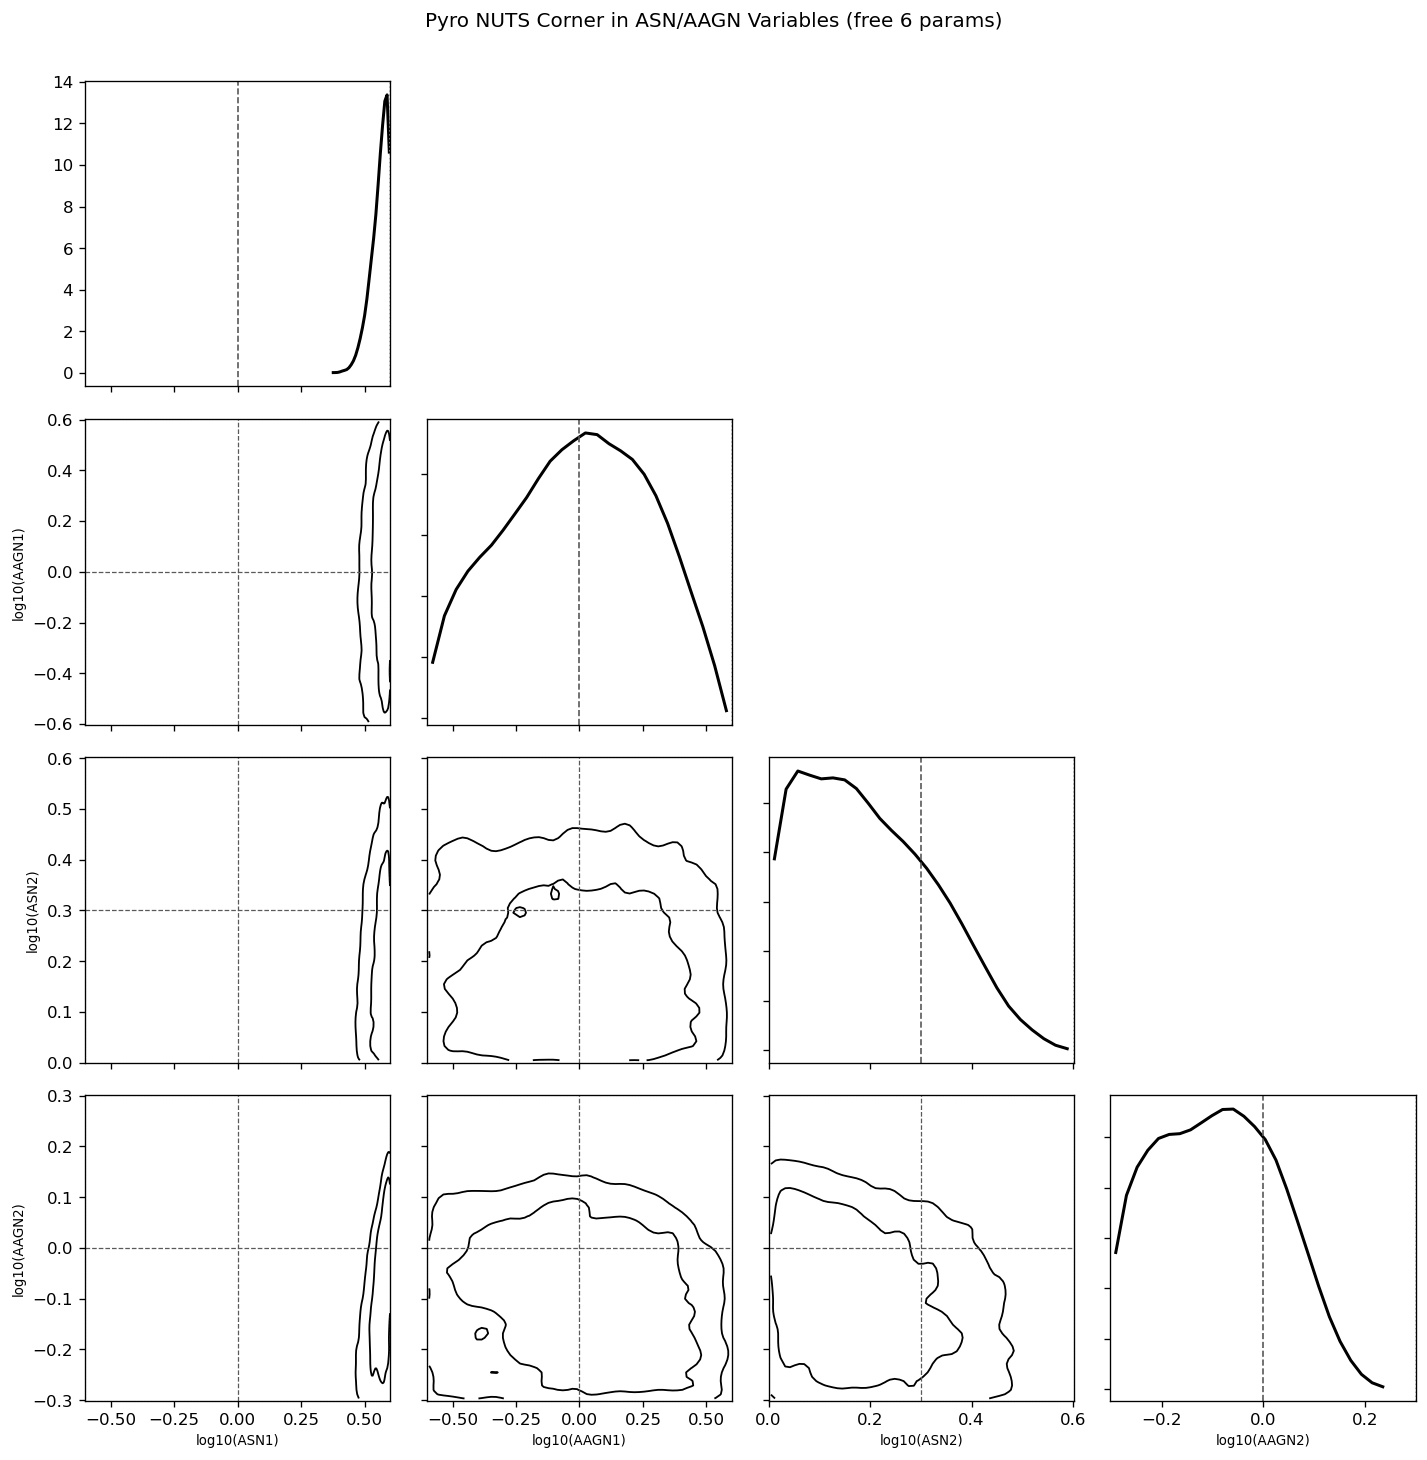

In [7]:
# Generate clean corner plots for every available free-set.
for free_key in sorted(chains_by_key.keys(), key=int):
    print(f'Corner plot for free-set {free_key}')
    corner_asn_aagn(chains_by_key[free_key])

In [8]:
def posterior_predictive_for_run(npz_obj, n_draw=120, pred_samples_per_theta=20):
    samples = np.asarray(npz_obj['samples'], dtype=float)
    batch_idxs = np.asarray(npz_obj['batch_idxs'], dtype=int)

    flat = samples.reshape(-1, samples.shape[-1])
    n_draw = min(n_draw, flat.shape[0])
    draw_idx = np.random.choice(flat.shape[0], size=n_draw, replace=False)
    theta_draws = flat[draw_idx]

    y_obs_log = obs.y_obs_log[batch_idxs, :, 0]
    sigma_obs = obs.sigma_obs_log[batch_idxs, :, 0]
    m_batch = obs.m500[batch_idxs]
    r_batch = obs.r_bins[batch_idxs]

    valid_obs = np.isfinite(y_obs_log) & np.isfinite(sigma_obs) & (sigma_obs < 1e5)
    temp_obs = np.power(10.0, y_obs_log)
    temp_obs[~valid_obs] = np.nan

    n_eff = np.sum(valid_obs, axis=0)
    support_mask = n_eff >= 3

    obs_stack = np.nanmean(temp_obs, axis=0)
    obs_sem = np.nanstd(temp_obs, axis=0) / np.sqrt(np.clip(n_eff, 1, None))
    obs_stack[~support_mask] = np.nan
    obs_sem[~support_mask] = np.nan

    pred_stacks = []
    for th in theta_draws:
        pred = emu.predict(
            theta=th,
            M=m_batch,
            r_bins=r_batch,
            field=['temperature'],
            snapnum=90,
            redshift=0.0,
            n_samples=pred_samples_per_theta,
        )
        pred_halo = pred.mean[:, :, 0]

        # Match observed stack support: only include halos with valid observed bins at each radius.
        pred_halo_masked = np.where(valid_obs, pred_halo, np.nan)
        pred_stack = np.nanmean(pred_halo_masked, axis=0)
        pred_stack[~support_mask] = np.nan
        pred_stacks.append(pred_stack)

    pred_stacks = np.asarray(pred_stacks)
    pred_med = np.nanmedian(pred_stacks, axis=0)
    pred_q16 = np.nanpercentile(pred_stacks, 16, axis=0)
    pred_q84 = np.nanpercentile(pred_stacks, 84, axis=0)

    rr = obs.r_bins[0]
    mask_eval = np.isfinite(obs_stack) & np.isfinite(obs_sem)

    rmse = float(np.sqrt(np.mean((obs_stack[mask_eval] - pred_med[mask_eval]) ** 2))) if np.any(mask_eval) else np.nan
    coverage68 = float(np.mean((obs_stack[mask_eval] >= pred_q16[mask_eval]) & (obs_stack[mask_eval] <= pred_q84[mask_eval]))) if np.any(mask_eval) else np.nan

    core_mask = mask_eval & (rr < 0.1)
    core_rmse = float(np.sqrt(np.mean((obs_stack[core_mask] - pred_med[core_mask]) ** 2))) if np.any(core_mask) else np.nan
    core_bias = float(np.mean(pred_med[core_mask] - obs_stack[core_mask])) if np.any(core_mask) else np.nan
    core_coverage68 = float(np.mean((obs_stack[core_mask] >= pred_q16[core_mask]) & (obs_stack[core_mask] <= pred_q84[core_mask]))) if np.any(core_mask) else np.nan

    return {
        'rr': rr,
        'obs_stack': obs_stack,
        'obs_sem': obs_sem,
        'pred_med': pred_med,
        'pred_q16': pred_q16,
        'pred_q84': pred_q84,
        'rmse_keV': rmse,
        'coverage68': coverage68,
        'core_rmse_keV': core_rmse,
        'core_bias_keV': core_bias,
        'core_coverage68': core_coverage68,
        'n_halos': int(len(batch_idxs)),
        'n_eff': n_eff,
        'n_core_bins': int(np.sum(core_mask)),
    }

Running posterior predictive for free-set 4...


/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


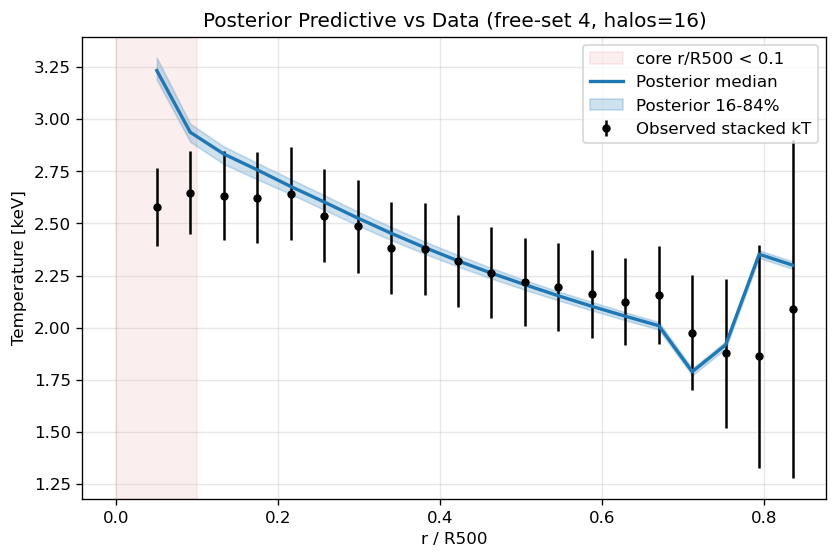

free-set 4: total RMSE=0.2161 keV, total 68% coverage=0.250; core RMSE=0.5057 keV, core bias=0.4716 keV, core 68% coverage=0.000, core bins=2
Running posterior predictive for free-set 6...


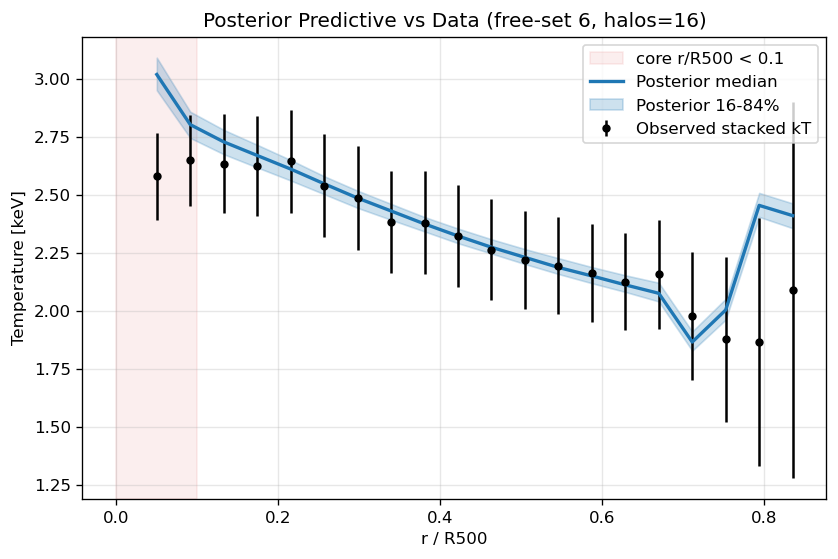

free-set 6: total RMSE=0.1893 keV, total 68% coverage=0.550; core RMSE=0.3285 keV, core bias=0.2960 keV, core 68% coverage=0.000, core bins=2


In [9]:
# Run posterior predictive checks for each free-set and plot against data.
ppc_results = {}
for free_key in sorted(chains_by_key.keys(), key=int):
    print(f'Running posterior predictive for free-set {free_key}...')
    out = posterior_predictive_for_run(chains_by_key[free_key], n_draw=120, pred_samples_per_theta=20)
    ppc_results[free_key] = out

    rr = out['rr']
    m = np.isfinite(out['obs_stack']) & np.isfinite(out['obs_sem']) & (out['n_eff'] >= 3)

    plt.figure(figsize=(8, 5))
    plt.axvspan(0.0, 0.1, color='tab:red', alpha=0.08, label='core r/R500 < 0.1')
    plt.errorbar(rr[m], out['obs_stack'][m], yerr=out['obs_sem'][m], fmt='o', ms=4, color='black', label='Observed stacked kT')
    plt.plot(rr, out['pred_med'], lw=2.0, color='tab:blue', label='Posterior median')
    plt.fill_between(rr, out['pred_q16'], out['pred_q84'], color='tab:blue', alpha=0.22, label='Posterior 16-84%')
    plt.xlabel('r / R500')
    plt.ylabel('Temperature [keV]')
    plt.title(f'Posterior Predictive vs Data (free-set {free_key}, halos={out["n_halos"]})')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    print(
        f"free-set {free_key}: total RMSE={out['rmse_keV']:.4f} keV, total 68% coverage={out['coverage68']:.3f}; "
        f"core RMSE={out['core_rmse_keV']:.4f} keV, core bias={out['core_bias_keV']:.4f} keV, "
        f"core 68% coverage={out['core_coverage68']:.3f}, core bins={out['n_core_bins']}"
    )

In [10]:
# Compact comparison table across free-parameter runs, including core-region metrics.
rows = []
for k in sorted(ppc_results.keys(), key=int):
    rows.append({
        'free_set': k,
        'n_halos': ppc_results[k]['n_halos'],
        'rmse_keV': ppc_results[k]['rmse_keV'],
        'coverage68': ppc_results[k]['coverage68'],
        'core_rmse_keV': ppc_results[k]['core_rmse_keV'],
        'core_bias_keV': ppc_results[k]['core_bias_keV'],
        'core_coverage68': ppc_results[k]['core_coverage68'],
        'n_core_bins': ppc_results[k]['n_core_bins'],
    })

display(pd.DataFrame(rows).sort_values('free_set'))

,free_set,n_halos,rmse_keV,coverage68,core_rmse_keV,core_bias_keV,core_coverage68,n_core_bins
0,4,16,0.216097,0.25,0.505743,0.471597,0.0,2
1,6,16,0.189348,0.55,0.328522,0.295989,0.0,2


In [15]:
# Quick diagnostic: boundary-hugging and posterior width in ASN/AAGN variables
diag_specs = [
    {'raw_name': 'WindEnergyIn1e51erg', 'plot_name': 'ASN1', 'scale': 3.6},
    {'raw_name': 'RadioFeedbackFactor', 'plot_name': 'AAGN1', 'scale': 1.0},
    {'raw_name': 'VariableWindVelFactor', 'plot_name': 'ASN2', 'scale': 3.7},
    {'raw_name': 'RadioFeedbackReiorientationFactor', 'plot_name': 'AAGN2', 'scale': 20.0},
]

rows = []
eps = 0.01  # 1% prior-edge neighborhood
for free_key, z in sorted(chains_by_key.items(), key=lambda t: int(t[0])):
    theta_cols = [str(x) for x in z['theta_cols']]
    samples = np.asarray(z['samples'], dtype=float).reshape(-1, z['samples'].shape[-1])
    prior_lo = np.asarray(z['prior_lo_run'], dtype=float)
    prior_hi = np.asarray(z['prior_hi_run'], dtype=float)

    for spec in diag_specs:
        if spec['raw_name'] not in theta_cols:
            continue
        j = theta_cols.index(spec['raw_name'])
        x = samples[:, j]
        lo, hi = float(prior_lo[j]), float(prior_hi[j])
        w = max(hi - lo, 1e-12)
        low_thr = lo + eps * w
        high_thr = hi - eps * w
        frac_low = float(np.mean(x <= low_thr))
        frac_high = float(np.mean(x >= high_thr))
        frac_edge = float(np.mean((x <= low_thr) | (x >= high_thr)))

        # Width in transformed log10 variable, normalized by transformed prior width
        x_t = np.log10(np.clip(x / spec['scale'], 1e-300, None))
        lo_t = np.log10(max(lo / spec['scale'], 1e-300))
        hi_t = np.log10(max(hi / spec['scale'], 1e-300))
        prior_w_t = max(hi_t - lo_t, 1e-12)
        post_std_t = float(np.nanstd(x_t))
        post_std_over_prior = post_std_t / prior_w_t

        rows.append({
            'free_set': free_key,
            'param': spec['plot_name'],
            'edge_frac_1pct': frac_edge,
            'high_edge_frac_1pct': frac_high,
            'low_edge_frac_1pct': frac_low,
            'post_std_over_prior_width': post_std_over_prior,
        })

diag_df = pd.DataFrame(rows)
display(diag_df.sort_values(['free_set', 'edge_frac_1pct'], ascending=[True, False]))

if 'ppc_results' in globals():
    ppc_df = pd.DataFrame([
        {
            'free_set': k,
            'rmse_keV': v['rmse_keV'],
            'coverage68': v['coverage68'],
            'n_halos': v['n_halos'],
        }
        for k, v in sorted(ppc_results.items(), key=lambda t: int(t[0]))
    ])
    print('\nPPC summary:')
    display(ppc_df)

,free_set,param,edge_frac_1pct,high_edge_frac_1pct,low_edge_frac_1pct,post_std_over_prior_width
0,4,ASN1,0.098708,0.098708,0.000000,0.020418
1,4,AAGN1,0.044125,0.000000,0.044125,0.224966
3,4,AAGN2,0.029833,0.000000,0.029833,0.183564
2,4,ASN2,0.009000,0.000208,0.008792,0.221412
4,6,ASN1,0.069125,0.069125,0.000000,0.028897
6,6,ASN2,0.036833,0.000083,0.036750,0.211166
5,6,AAGN1,0.032583,0.000625,0.031958,0.247410
7,6,AAGN2,0.022292,0.000000,0.022292,0.193555



PPC summary:


,free_set,rmse_keV,coverage68,n_halos
0,4,0.185525,0.30,16
1,6,0.121917,0.55,16


## Single-Halo Posterior Predictive

This view isolates one halo (with its own mass and radius bins) and compares observed temperature data to emulator posterior predictions for that same halo only.

free-set: 6
selected halo: CID28
batch local index: 0 / 15
kT file used: /mnt/home/mlee1/CPGP_xray/Data/data/kT/CID28_kt.dat
M500 [Msun]: 6.760e+13
valid bins (raw): 24, core valid bins: 2
RMSE=0.1752 keV, core RMSE=0.1247 keV, core bias=-0.0395 keV


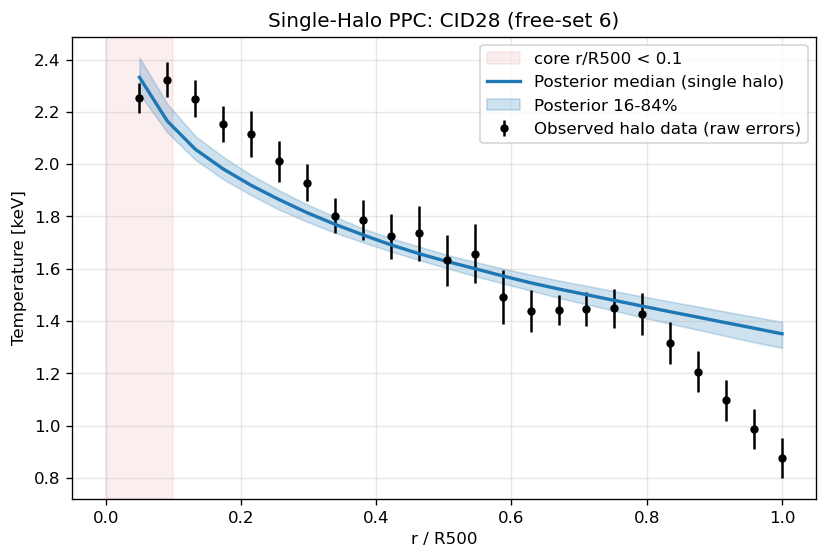

,batch_local_index,halo_name,core_valid_bins,total_valid_bins,M500_msun
0,0,CID28,2,24,6.759592e+13
1,1,A0496,2,21,4.187848e+14
2,2,A3570,2,20,7.970981e+13
3,3,CID36,2,18,9.527606e+13
4,4,A3390,2,18,5.746565e+13
5,5,A3733,2,18,8.836674e+13
6,6,NGC6107,2,18,7.703188e+13
7,7,A1185,2,17,6.896657e+13
8,8,AWM5,2,17,7.067573e+13
9,9,NGC7556,2,17,5.489155e+13


In [12]:
# Single-halo PPC: one halo, one mass, one radius grid
FREE_SET_SINGLE = '6'  # choose from keys in chains_by_key
N_DRAW_SINGLE = 120
PRED_SAMPLES_PER_DRAW_SINGLE = 20
HALO_MODE = 'best_core_coverage'  # options: 'best_core_coverage', 'first_in_batch', 'batch_local_index'
BATCH_LOCAL_INDEX = 0

if FREE_SET_SINGLE not in chains_by_key:
    raise KeyError(f'FREE_SET_SINGLE={FREE_SET_SINGLE} not in available keys {sorted(chains_by_key.keys())}')

npz_single = chains_by_key[FREE_SET_SINGLE]
samples_all = np.asarray(npz_single['samples'], dtype=float)
batch_idxs = np.asarray(npz_single['batch_idxs'], dtype=int)
batch_names = [str(x) for x in npz_single['batch_names']]

# Pick which halo from the fitted batch to inspect
core_bins = obs.r_bins[0] < 0.1
valid_by_halo = np.isfinite(obs.y_obs_log[batch_idxs, :, 0]) & (obs.sigma_obs_log[batch_idxs, :, 0] < 1e5)
core_valid_counts = np.sum(valid_by_halo[:, core_bins], axis=1)
total_valid_counts = np.sum(valid_by_halo, axis=1)

if HALO_MODE == 'best_core_coverage':
    i_local = int(np.argmax(core_valid_counts))
elif HALO_MODE == 'first_in_batch':
    i_local = 0
elif HALO_MODE == 'batch_local_index':
    i_local = int(np.clip(BATCH_LOCAL_INDEX, 0, len(batch_idxs) - 1))
else:
    raise ValueError('HALO_MODE must be one of: best_core_coverage, first_in_batch, batch_local_index')

i_global = int(batch_idxs[i_local])
halo_name = str(obs.names[i_global])
M_single = obs.m500[i_global:i_global + 1]
r_single = obs.r_bins[i_global:i_global + 1]
rr = r_single[0]

# Likelihood-space quantities (includes flooring); kept for reference only.
y_log_single = obs.y_obs_log[i_global, :, 0]
sig_log_single = obs.sigma_obs_log[i_global, :, 0]
y_keV_lik = np.power(10.0, y_log_single)
err_keV_lik = y_keV_lik * np.log(10.0) * sig_log_single

# Reconstruct raw observed temperature and raw measurement errors from original file.
import re

def _norm_name(x: str) -> str:
    return re.sub(r'[^A-Z0-9]', '', str(x).upper())

catalog_by_norm = {}
with open(catalog_path, 'r', encoding='utf-8') as fh:
    for line in fh:
        s = line.strip()
        if (not s) or s.startswith('#'):
            continue
        parts = s.split()
        if len(parts) < 7:
            continue
        catalog_by_norm[_norm_name(parts[0])] = {
            'z': float(parts[3]),
            'r500_arcmin': float(parts[6]),
        }

cat_row = catalog_by_norm.get(_norm_name(halo_name), None)
if cat_row is None:
    raise RuntimeError(f'Could not find catalog row for halo {halo_name}')

kt_file = kt_dir / f'{halo_name}_kt.dat'
if not kt_file.exists():
    # Fallback by normalized-name matching.
    candidates = list(kt_dir.glob('*_kt.dat'))
    found = None
    for fp in candidates:
        base = fp.stem.replace('_kt', '')
        if _norm_name(base) == _norm_name(halo_name):
            found = fp
            break
    if found is None:
        raise FileNotFoundError(f'Could not find kT file for halo {halo_name} in {kt_dir}')
    kt_file = found

arr = np.genfromtxt(
    kt_file,
    dtype=float,
    comments='#',
    usecols=(0, 4, 5, 6),
    invalid_raise=False,
    ndmin=2,
    )
if arr.size == 0:
    raise RuntimeError(f'Empty kT file for halo {halo_name}: {kt_file}')

r_arcmin = arr[:, 0]
t_keV = arr[:, 1]
e_lo = np.abs(arr[:, 2])
e_hi = np.abs(arr[:, 3])
e_keV = 0.5 * (e_lo + e_hi)
mraw = np.isfinite(r_arcmin) & np.isfinite(t_keV) & np.isfinite(e_keV) & (t_keV > 0)
if np.sum(mraw) < 5:
    raise RuntimeError(f'Insufficient valid rows in {kt_file} for halo {halo_name}')

r500_arcmin = float(cat_row['r500_arcmin'])
r_over_r500 = r_arcmin[mraw] / r500_arcmin
y_keV_raw = np.interp(rr, r_over_r500, t_keV[mraw], left=np.nan, right=np.nan)
err_keV_raw = np.interp(rr, r_over_r500, e_keV[mraw], left=np.nan, right=np.nan)
valid_raw = np.isfinite(y_keV_raw) & np.isfinite(err_keV_raw) & (y_keV_raw > 0)

# Draw theta samples from posterior for this free set
flat = samples_all.reshape(-1, samples_all.shape[-1])
n_draw = min(N_DRAW_SINGLE, flat.shape[0])
draw_idx = np.random.choice(flat.shape[0], size=n_draw, replace=False)
theta_draws = flat[draw_idx]

pred_profiles = []
for th in theta_draws:
    pred = emu.predict(
        theta=th,
        M=M_single,
        r_bins=r_single,
        field=['temperature'],
        snapnum=90,
        redshift=0.0,
        n_samples=PRED_SAMPLES_PER_DRAW_SINGLE,
    )
    pred_profiles.append(pred.mean[0, :, 0])

pred_profiles = np.asarray(pred_profiles)
pred_med = np.nanmedian(pred_profiles, axis=0)
pred_q16 = np.nanpercentile(pred_profiles, 16, axis=0)
pred_q84 = np.nanpercentile(pred_profiles, 84, axis=0)

eval_mask = valid_raw & np.isfinite(pred_med)
core_mask = eval_mask & (rr < 0.1)
rmse = float(np.sqrt(np.mean((y_keV_raw[eval_mask] - pred_med[eval_mask]) ** 2))) if np.any(eval_mask) else np.nan
core_rmse = float(np.sqrt(np.mean((y_keV_raw[core_mask] - pred_med[core_mask]) ** 2))) if np.any(core_mask) else np.nan
core_bias = float(np.mean(pred_med[core_mask] - y_keV_raw[core_mask])) if np.any(core_mask) else np.nan

print(f'free-set: {FREE_SET_SINGLE}')
print(f'selected halo: {halo_name}')
print(f'batch local index: {i_local} / {len(batch_idxs)-1}')
print(f'kT file used: {kt_file}')
print(f'M500 [Msun]: {float(M_single[0]):.3e}')
print(f'valid bins (raw): {int(np.sum(eval_mask))}, core valid bins: {int(np.sum(core_mask))}')
print(f'RMSE={rmse:.4f} keV, core RMSE={core_rmse:.4f} keV, core bias={core_bias:.4f} keV')

plt.figure(figsize=(8, 5))
plt.axvspan(0.0, 0.1, color='tab:red', alpha=0.08, label='core r/R500 < 0.1')
plt.errorbar(rr[valid_raw], y_keV_raw[valid_raw], yerr=err_keV_raw[valid_raw], fmt='o', ms=4, color='black', label='Observed halo data (raw errors)')
plt.plot(rr, pred_med, lw=2.0, color='tab:blue', label='Posterior median (single halo)')
plt.fill_between(rr, pred_q16, pred_q84, color='tab:blue', alpha=0.22, label='Posterior 16-84%')
plt.xlabel('r / R500')
plt.ylabel('Temperature [keV]')
plt.title(f'Single-Halo PPC: {halo_name} (free-set {FREE_SET_SINGLE})')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Optional context table: all halos in current fitted batch
batch_table = pd.DataFrame({
    'batch_local_index': np.arange(len(batch_idxs), dtype=int),
    'halo_name': batch_names,
    'core_valid_bins': core_valid_counts,
    'total_valid_bins': total_valid_counts,
    'M500_msun': obs.m500[batch_idxs],
})
display(batch_table.sort_values(['core_valid_bins', 'total_valid_bins'], ascending=False))

## Population Study (Per-Halo PPC)

This section evaluates posterior predictive fit quality halo-by-halo for a selected free-set.

It uses each halo's own mass, radius bins, and raw observed kT uncertainties from the source data files, then reports a population table and summary plots.

Population study completed for free-set 6 with 16 halos and 40 posterior draws per halo.


,halo_name,batch_local_index,M500_msun,n_valid_bins,n_core_bins,rmse_keV,bias_keV,coverage68,chi2_red_raw_errors,core_rmse_keV,core_bias_keV,core_coverage68
1,A0496,1,4.187848e+14,21,2,1.194323,1.023820,0.000000,4943.955406,2.507927,2.478970,0.0
10,NGC1650,10,9.543786e+13,17,2,0.877719,-0.841015,0.000000,7.869981,0.859152,-0.831096,0.0
14,A2657,14,2.492284e+14,16,2,0.655807,0.613617,0.000000,15.899005,0.720394,0.710589,0.0
3,CID36,3,9.527606e+13,18,2,0.468034,0.427692,0.000000,34.208163,0.592368,0.519428,0.0
4,A3390,4,5.746565e+13,18,2,0.181717,0.119965,0.111111,8.308081,0.415319,0.415151,0.0
6,NGC6107,6,7.703188e+13,18,2,0.794805,-0.610132,0.000000,7.337796,0.402313,0.373104,0.0
9,NGC7556,9,5.489155e+13,17,2,0.225457,0.220938,0.000000,48.294237,0.283160,0.281184,0.0
2,A3570,2,7.970981e+13,20,2,0.320606,0.136362,0.000000,28.956078,0.265515,0.265082,0.0
11,ZWCL1665,11,4.894576e+13,16,2,0.114883,0.091261,0.125000,3.011886,0.248022,0.240055,0.0
12,A0076,12,2.169197e+14,16,2,0.175544,0.092620,0.187500,0.181905,0.242715,0.227137,0.0


,metric,median,p16,p84
0,rmse_keV,0.242864,0.174401,0.801875
1,coverage68,0.029412,0.000000,0.125000
2,chi2_red_raw_errors,7.363958,3.406445,32.107329
3,core_rmse_keV,0.256768,0.205302,0.669184
4,core_coverage68,0.000000,0.000000,0.000000


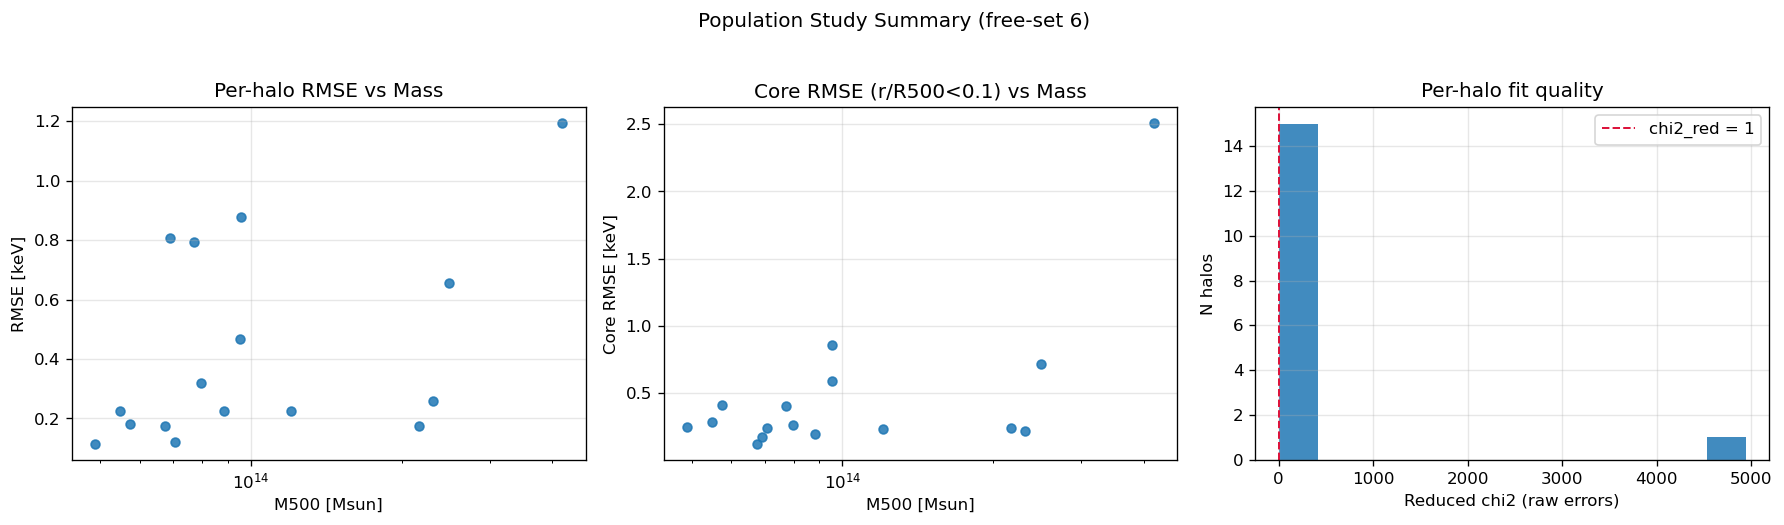

In [13]:
# Population study: per-halo posterior predictive diagnostics
FREE_SET_POP = '6'  # choose from available keys in chains_by_key
N_DRAW_POP = 40  # increase for more stable estimates
PRED_SAMPLES_PER_DRAW_POP = 20

if FREE_SET_POP not in chains_by_key:
    raise KeyError(f'FREE_SET_POP={FREE_SET_POP} not in available keys {sorted(chains_by_key.keys())}')

npz_pop = chains_by_key[FREE_SET_POP]
samples_all = np.asarray(npz_pop['samples'], dtype=float)
batch_idxs = np.asarray(npz_pop['batch_idxs'], dtype=int)
batch_names = [str(x) for x in npz_pop['batch_names']]

flat = samples_all.reshape(-1, samples_all.shape[-1])
n_draw = min(N_DRAW_POP, flat.shape[0])
draw_idx = np.random.choice(flat.shape[0], size=n_draw, replace=False)
theta_draws = flat[draw_idx]

import re
def _norm_name(x: str) -> str:
    return re.sub(r'[^A-Z0-9]', '', str(x).upper())

# Parse catalog once
catalog_by_norm = {}
with open(catalog_path, 'r', encoding='utf-8') as fh:
    for line in fh:
        s = line.strip()
        if (not s) or s.startswith('#'):
            continue
        parts = s.split()
        if len(parts) < 7:
            continue
        catalog_by_norm[_norm_name(parts[0])] = {
            'z': float(parts[3]),
            'r500_arcmin': float(parts[6]),
        }

def load_raw_halo_profile_on_grid(halo_name: str, rr_grid: np.ndarray):
    row = catalog_by_norm.get(_norm_name(halo_name), None)
    if row is None:
        return None, None

    kt_file = kt_dir / f'{halo_name}_kt.dat'
    if not kt_file.exists():
        found = None
        for fp in kt_dir.glob('*_kt.dat'):
            if _norm_name(fp.stem.replace('_kt', '')) == _norm_name(halo_name):
                found = fp
                break
        if found is None:
            return None, None
        kt_file = found

    arr = np.genfromtxt(
        kt_file,
        dtype=float,
        comments='#',
        usecols=(0, 4, 5, 6),
        invalid_raise=False,
        ndmin=2,
    )
    if arr.size == 0:
        return None, None

    r_arcmin = arr[:, 0]
    t_keV = arr[:, 1]
    e_lo = np.abs(arr[:, 2])
    e_hi = np.abs(arr[:, 3])
    e_keV = 0.5 * (e_lo + e_hi)

    m = np.isfinite(r_arcmin) & np.isfinite(t_keV) & np.isfinite(e_keV) & (t_keV > 0)
    if np.sum(m) < 5:
        return None, None

    r500_arcmin = float(row['r500_arcmin'])
    r_over_r500 = r_arcmin[m] / r500_arcmin
    y = np.interp(rr_grid, r_over_r500, t_keV[m], left=np.nan, right=np.nan)
    e = np.interp(rr_grid, r_over_r500, e_keV[m], left=np.nan, right=np.nan)
    return y, e

rows = []
for i_local, i_global in enumerate(batch_idxs):
    halo_name = str(obs.names[i_global])
    rr = obs.r_bins[i_global]
    M_h = obs.m500[i_global:i_global+1]
    r_h = obs.r_bins[i_global:i_global+1]

    y_raw, e_raw = load_raw_halo_profile_on_grid(halo_name, rr)
    if y_raw is None:
        continue

    valid = np.isfinite(y_raw) & np.isfinite(e_raw) & (y_raw > 0) & (e_raw > 0)
    core = valid & (rr < 0.1)
    if np.sum(valid) < 5:
        continue

    pred_profiles = []
    for th in theta_draws:
        pred = emu.predict(
            theta=th,
            M=M_h,
            r_bins=r_h,
            field=['temperature'],
            snapnum=90,
            redshift=0.0,
            n_samples=PRED_SAMPLES_PER_DRAW_POP,
        )
        pred_profiles.append(pred.mean[0, :, 0])
    pred_profiles = np.asarray(pred_profiles)

    pred_med = np.nanmedian(pred_profiles, axis=0)
    pred_q16 = np.nanpercentile(pred_profiles, 16, axis=0)
    pred_q84 = np.nanpercentile(pred_profiles, 84, axis=0)

    resid = pred_med[valid] - y_raw[valid]
    rmse = float(np.sqrt(np.mean(resid ** 2)))
    bias = float(np.mean(resid))
    coverage68 = float(np.mean((y_raw[valid] >= pred_q16[valid]) & (y_raw[valid] <= pred_q84[valid])))

    chi2_red = float(np.sum(((y_raw[valid] - pred_med[valid]) / np.clip(e_raw[valid], 1e-8, None)) ** 2) / max(np.sum(valid) - 1, 1))

    if np.any(core):
        core_resid = pred_med[core] - y_raw[core]
        core_rmse = float(np.sqrt(np.mean(core_resid ** 2)))
        core_bias = float(np.mean(core_resid))
        core_coverage68 = float(np.mean((y_raw[core] >= pred_q16[core]) & (y_raw[core] <= pred_q84[core])))
    else:
        core_rmse = np.nan
        core_bias = np.nan
        core_coverage68 = np.nan

    rows.append({
        'halo_name': halo_name,
        'batch_local_index': i_local,
        'M500_msun': float(obs.m500[i_global]),
        'n_valid_bins': int(np.sum(valid)),
        'n_core_bins': int(np.sum(core)),
        'rmse_keV': rmse,
        'bias_keV': bias,
        'coverage68': coverage68,
        'chi2_red_raw_errors': chi2_red,
        'core_rmse_keV': core_rmse,
        'core_bias_keV': core_bias,
        'core_coverage68': core_coverage68,
    })

pop_df = pd.DataFrame(rows)
if len(pop_df) == 0:
    raise RuntimeError('Population table is empty; no usable per-halo profiles found.')

print(f'Population study completed for free-set {FREE_SET_POP} with {len(pop_df)} halos and {n_draw} posterior draws per halo.')
display(pop_df.sort_values('core_rmse_keV', ascending=False))

summary = pd.DataFrame({
    'metric': ['rmse_keV', 'coverage68', 'chi2_red_raw_errors', 'core_rmse_keV', 'core_coverage68'],
    'median': [
        float(np.nanmedian(pop_df['rmse_keV'])),
        float(np.nanmedian(pop_df['coverage68'])),
        float(np.nanmedian(pop_df['chi2_red_raw_errors'])),
        float(np.nanmedian(pop_df['core_rmse_keV'])),
        float(np.nanmedian(pop_df['core_coverage68'])),
    ],
    'p16': [
        float(np.nanpercentile(pop_df['rmse_keV'], 16)),
        float(np.nanpercentile(pop_df['coverage68'], 16)),
        float(np.nanpercentile(pop_df['chi2_red_raw_errors'], 16)),
        float(np.nanpercentile(pop_df['core_rmse_keV'].dropna(), 16)) if np.any(np.isfinite(pop_df['core_rmse_keV'])) else np.nan,
        float(np.nanpercentile(pop_df['core_coverage68'].dropna(), 16)) if np.any(np.isfinite(pop_df['core_coverage68'])) else np.nan,
    ],
    'p84': [
        float(np.nanpercentile(pop_df['rmse_keV'], 84)),
        float(np.nanpercentile(pop_df['coverage68'], 84)),
        float(np.nanpercentile(pop_df['chi2_red_raw_errors'], 84)),
        float(np.nanpercentile(pop_df['core_rmse_keV'].dropna(), 84)) if np.any(np.isfinite(pop_df['core_rmse_keV'])) else np.nan,
        float(np.nanpercentile(pop_df['core_coverage68'].dropna(), 84)) if np.any(np.isfinite(pop_df['core_coverage68'])) else np.nan,
    ],
})
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(pop_df['M500_msun'], pop_df['rmse_keV'], s=28, alpha=0.85)
axes[0].set_xscale('log')
axes[0].set_xlabel('M500 [Msun]')
axes[0].set_ylabel('RMSE [keV]')
axes[0].set_title('Per-halo RMSE vs Mass')
axes[0].grid(alpha=0.3)

axes[1].scatter(pop_df['M500_msun'], pop_df['core_rmse_keV'], s=28, alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_xlabel('M500 [Msun]')
axes[1].set_ylabel('Core RMSE [keV]')
axes[1].set_title('Core RMSE (r/R500<0.1) vs Mass')
axes[1].grid(alpha=0.3)

axes[2].hist(pop_df['chi2_red_raw_errors'], bins=12, alpha=0.85)
axes[2].axvline(1.0, color='crimson', ls='--', lw=1.2, label='chi2_red = 1')
axes[2].set_xlabel('Reduced chi2 (raw errors)')
axes[2].set_ylabel('N halos')
axes[2].set_title('Per-halo fit quality')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f'Population Study Summary (free-set {FREE_SET_POP})', y=1.03)
plt.tight_layout()
plt.show()

## 16-Panel Per-Halo Emulator Comparison

This grid shows each fitted halo separately (up to 16 halos): raw observed kT points with raw measurement errors, plus emulator posterior median and 16-84% band for that halo.

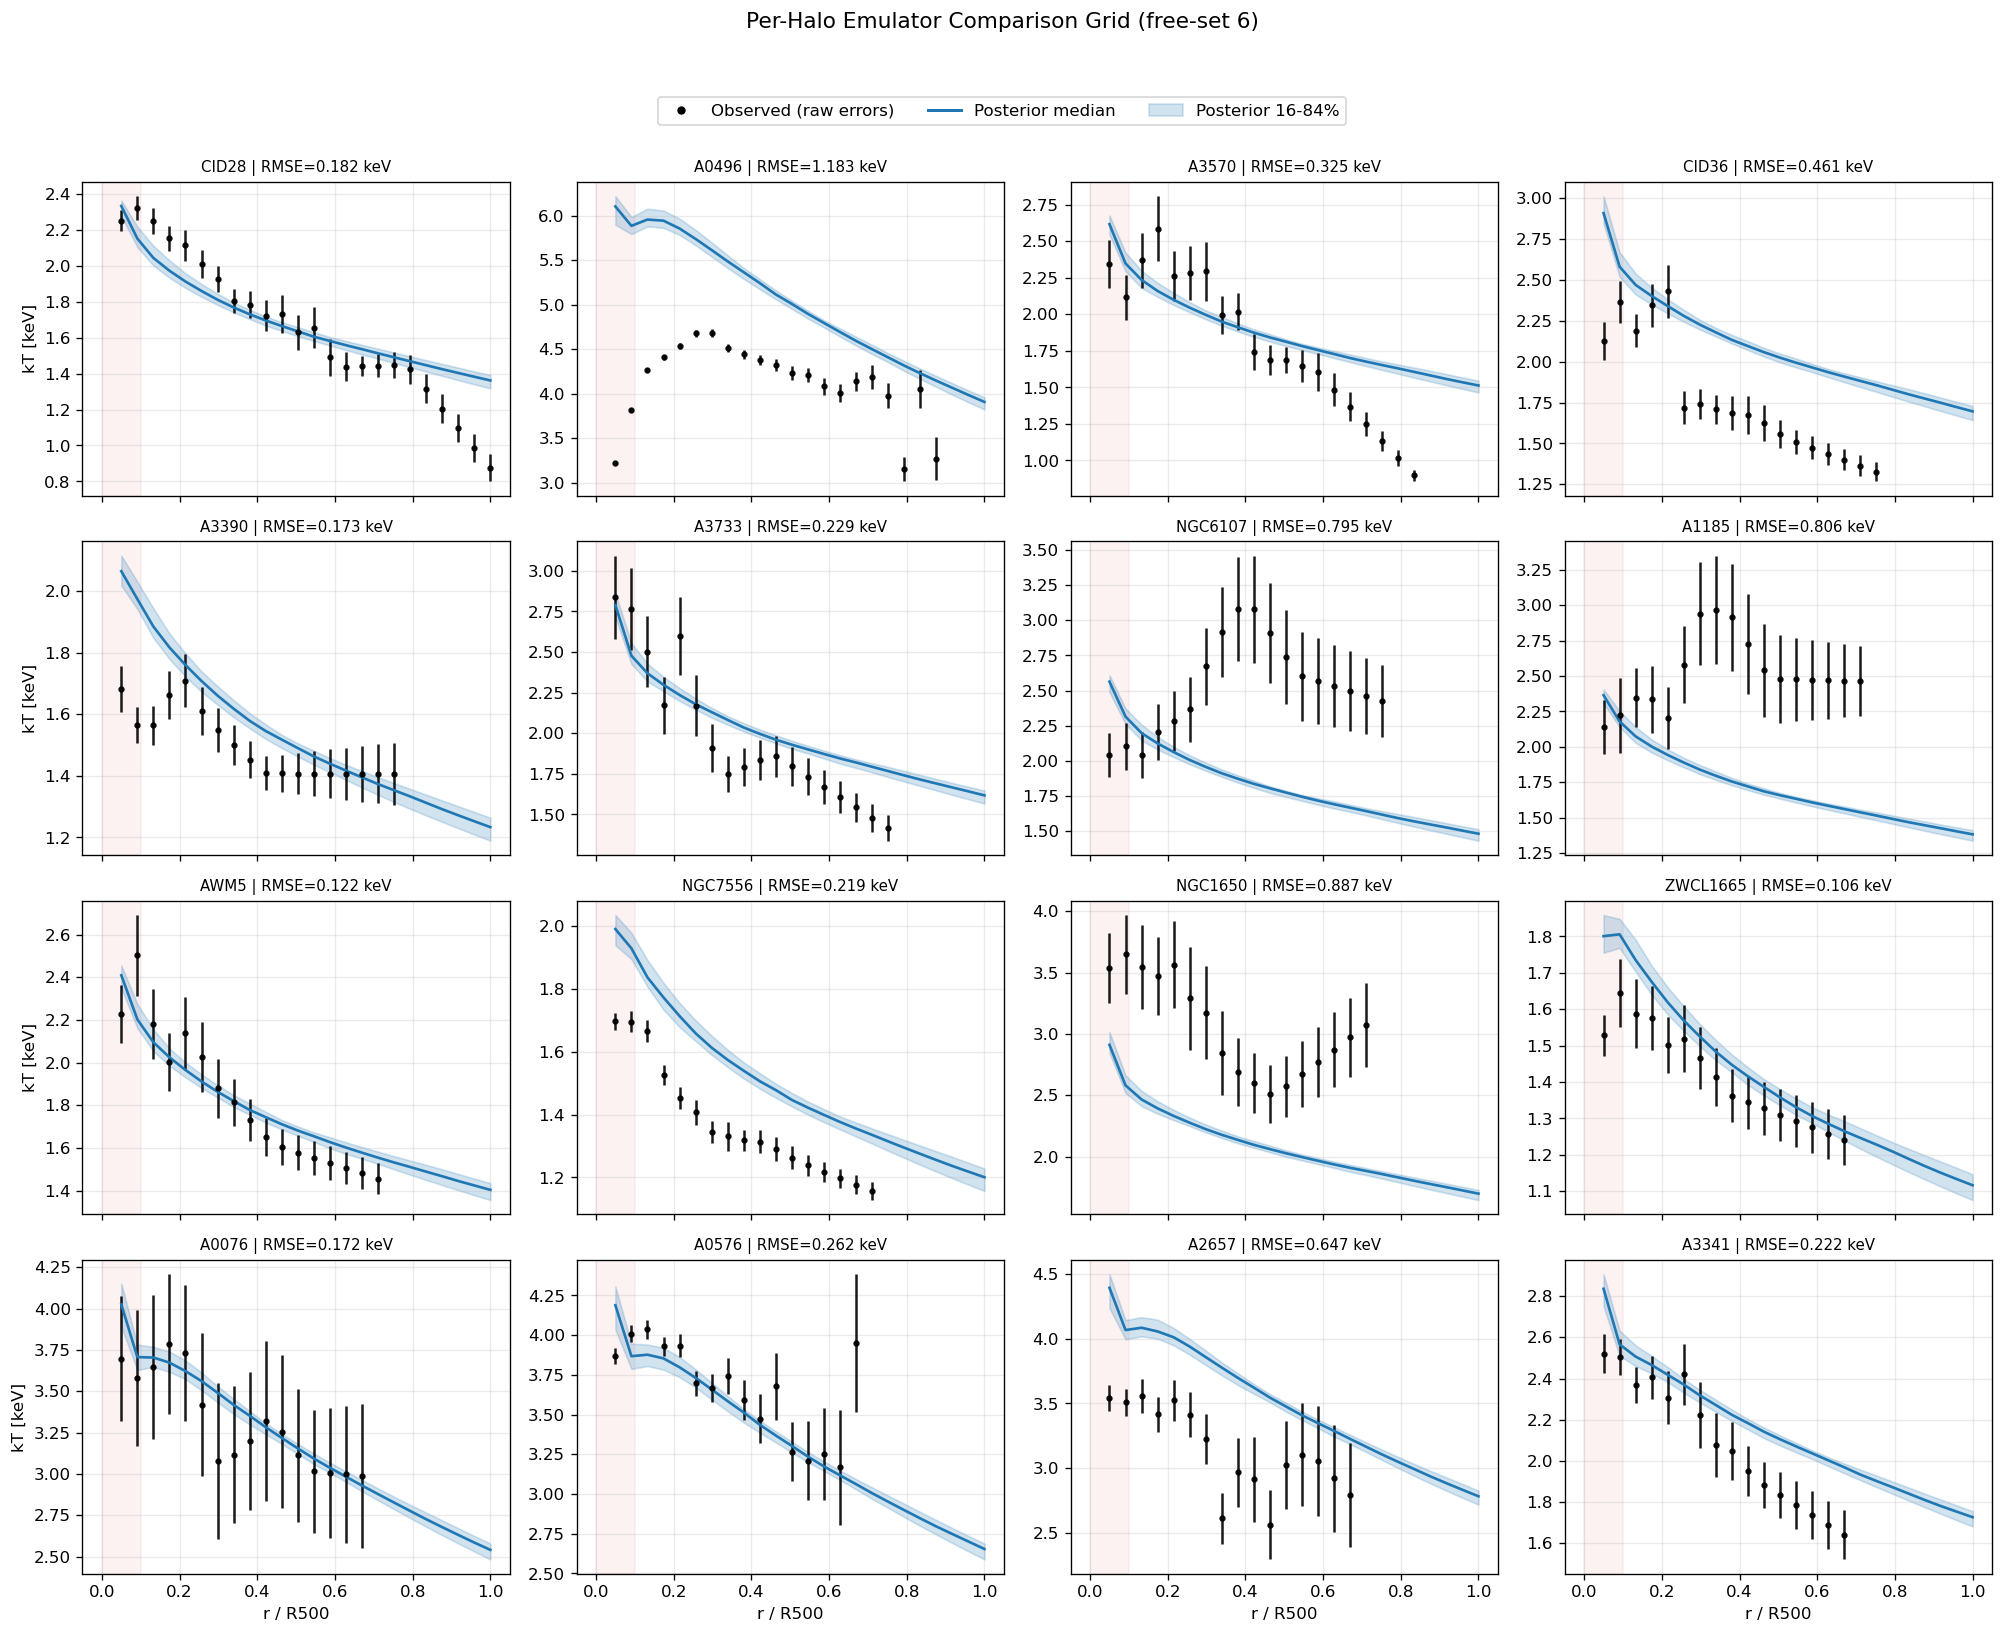

In [14]:
# 16-panel plot: one panel per halo with posterior emulator prediction
FREE_SET_GRID = FREE_SET_POP if 'FREE_SET_POP' in globals() else '6'
N_DRAW_GRID = 40
PRED_SAMPLES_PER_DRAW_GRID = 20
MAX_PANELS = 16

if FREE_SET_GRID not in chains_by_key:
    raise KeyError(f'FREE_SET_GRID={FREE_SET_GRID} not in available keys {sorted(chains_by_key.keys())}')

npz_grid = chains_by_key[FREE_SET_GRID]
samples_all = np.asarray(npz_grid['samples'], dtype=float)
batch_idxs = np.asarray(npz_grid['batch_idxs'], dtype=int)
batch_names = [str(x) for x in npz_grid['batch_names']]

flat = samples_all.reshape(-1, samples_all.shape[-1])
n_draw = min(N_DRAW_GRID, flat.shape[0])
draw_idx = np.random.choice(flat.shape[0], size=n_draw, replace=False)
theta_draws = flat[draw_idx]

import re
def _norm_name(x: str) -> str:
    return re.sub(r'[^A-Z0-9]', '', str(x).upper())

catalog_by_norm = {}
with open(catalog_path, 'r', encoding='utf-8') as fh:
    for line in fh:
        s = line.strip()
        if (not s) or s.startswith('#'):
            continue
        parts = s.split()
        if len(parts) < 7:
            continue
        catalog_by_norm[_norm_name(parts[0])] = {'r500_arcmin': float(parts[6])}

def load_raw_halo_profile_on_grid(halo_name: str, rr_grid: np.ndarray):
    row = catalog_by_norm.get(_norm_name(halo_name), None)
    if row is None:
        return None, None

    kt_file = kt_dir / f'{halo_name}_kt.dat'
    if not kt_file.exists():
        found = None
        for fp in kt_dir.glob('*_kt.dat'):
            if _norm_name(fp.stem.replace('_kt', '')) == _norm_name(halo_name):
                found = fp
                break
        if found is None:
            return None, None
        kt_file = found

    arr = np.genfromtxt(
        kt_file, dtype=float, comments='#', usecols=(0, 4, 5, 6), invalid_raise=False, ndmin=2
    )
    if arr.size == 0:
        return None, None

    r_arcmin = arr[:, 0]
    t_keV = arr[:, 1]
    e_lo = np.abs(arr[:, 2])
    e_hi = np.abs(arr[:, 3])
    e_keV = 0.5 * (e_lo + e_hi)

    m = np.isfinite(r_arcmin) & np.isfinite(t_keV) & np.isfinite(e_keV) & (t_keV > 0)
    if np.sum(m) < 5:
        return None, None

    r500_arcmin = float(row['r500_arcmin'])
    r_over_r500 = r_arcmin[m] / r500_arcmin
    y = np.interp(rr_grid, r_over_r500, t_keV[m], left=np.nan, right=np.nan)
    e = np.interp(rr_grid, r_over_r500, e_keV[m], left=np.nan, right=np.nan)
    return y, e

panel_indices = list(range(min(MAX_PANELS, len(batch_idxs))))
n_panels = len(panel_indices)
n_cols = 4
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows), sharex=True)
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for p, i_local in enumerate(panel_indices):
    r = p // n_cols
    c = p % n_cols
    ax = axes[r, c]

    i_global = int(batch_idxs[i_local])
    halo_name = str(obs.names[i_global])
    rr = obs.r_bins[i_global]
    M_h = obs.m500[i_global:i_global+1]
    r_h = obs.r_bins[i_global:i_global+1]

    y_raw, e_raw = load_raw_halo_profile_on_grid(halo_name, rr)
    if y_raw is None:
        ax.set_title(f'{halo_name} (missing raw file)', fontsize=9)
        ax.axis('off')
        continue

    valid = np.isfinite(y_raw) & np.isfinite(e_raw) & (y_raw > 0) & (e_raw > 0)

    pred_profiles = []
    for th in theta_draws:
        pred = emu.predict(
            theta=th, M=M_h, r_bins=r_h, field=['temperature'], snapnum=90, redshift=0.0,
            n_samples=PRED_SAMPLES_PER_DRAW_GRID,
        )
        pred_profiles.append(pred.mean[0, :, 0])
    pred_profiles = np.asarray(pred_profiles)
    pred_med = np.nanmedian(pred_profiles, axis=0)
    pred_q16 = np.nanpercentile(pred_profiles, 16, axis=0)
    pred_q84 = np.nanpercentile(pred_profiles, 84, axis=0)

    ax.axvspan(0.0, 0.1, color='tab:red', alpha=0.06)
    ax.errorbar(rr[valid], y_raw[valid], yerr=e_raw[valid], fmt='o', ms=2.8, color='black', alpha=0.9)
    ax.plot(rr, pred_med, lw=1.6, color='tab:blue')
    ax.fill_between(rr, pred_q16, pred_q84, color='tab:blue', alpha=0.20)

    rmse = np.sqrt(np.nanmean((pred_med[valid] - y_raw[valid]) ** 2)) if np.any(valid) else np.nan
    ax.set_title(f'{halo_name} | RMSE={rmse:.3f} keV', fontsize=9)
    ax.grid(alpha=0.25)

    if r == n_rows - 1:
        ax.set_xlabel('r / R500')
    if c == 0:
        ax.set_ylabel('kT [keV]')

# Hide unused panels if n_panels < n_rows*n_cols
for p in range(n_panels, n_rows * n_cols):
    r = p // n_cols
    c = p % n_cols
    axes[r, c].axis('off')

handles = [
    plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=4, label='Observed (raw errors)'),
    plt.Line2D([0], [0], color='tab:blue', lw=1.8, label='Posterior median'),
    plt.Rectangle((0, 0), 1, 1, color='tab:blue', alpha=0.20, label='Posterior 16-84%'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.01))
plt.suptitle(f'Per-Halo Emulator Comparison Grid (free-set {FREE_SET_GRID})', y=1.06, fontsize=13)
plt.tight_layout()
plt.show()

## MAP vs Posterior Median (Per Halo)

This section performs deterministic best-fit optimization (MAP-like with bounds, no MCMC) per halo and compares those curves against posterior-median emulator curves.

Interpretation guide:
- If MAP is still bad in the same way as posterior median, the emulator/likelihood family is likely the bottleneck.
- If MAP is much better than posterior median, posterior inference/tuning may be the bottleneck.

MAP optimization completed for 16 halos (free-set 6).
Positive improvement means MAP fits better than posterior median.


,batch_local_index,halo_name,M500_msun,rmse_post,rmse_map,improvement_rmse,core_rmse_post,core_rmse_map,core_improvement_rmse
10,10,NGC1650,9.543786e+13,0.886247,0.277146,0.609102,0.856125,0.260703,0.595421
7,7,A1185,6.896657e+13,0.819151,0.429442,0.389708,0.175926,0.402963,-0.227037
1,1,A0496,4.187848e+14,1.178917,0.818737,0.360179,2.484259,1.953175,0.531084
14,14,A2657,2.492284e+14,0.641136,0.368235,0.272901,0.702704,0.332906,0.369798
6,6,NGC6107,7.703188e+13,0.807249,0.609970,0.197278,0.400177,0.508113,-0.107936
9,9,NGC7556,5.489155e+13,0.216743,0.071391,0.145352,0.287118,0.077702,0.209416
3,3,CID36,9.527606e+13,0.452724,0.323488,0.129236,0.585177,0.504880,0.080297
15,15,A3341,1.202362e+14,0.210755,0.120988,0.089767,0.220793,0.159590,0.061204
4,4,A3390,5.746565e+13,0.178895,0.104838,0.074057,0.420095,0.244823,0.175272
11,11,ZWCL1665,4.894576e+13,0.109944,0.039064,0.070880,0.249202,0.090816,0.158386


,metric,value
0,rmse_post_median,0.241700
1,rmse_map_median,0.199381
2,median_improvement,0.081912
3,core_rmse_post_median,0.256852
4,core_rmse_map_median,0.242472
5,core_median_improvement,0.096569


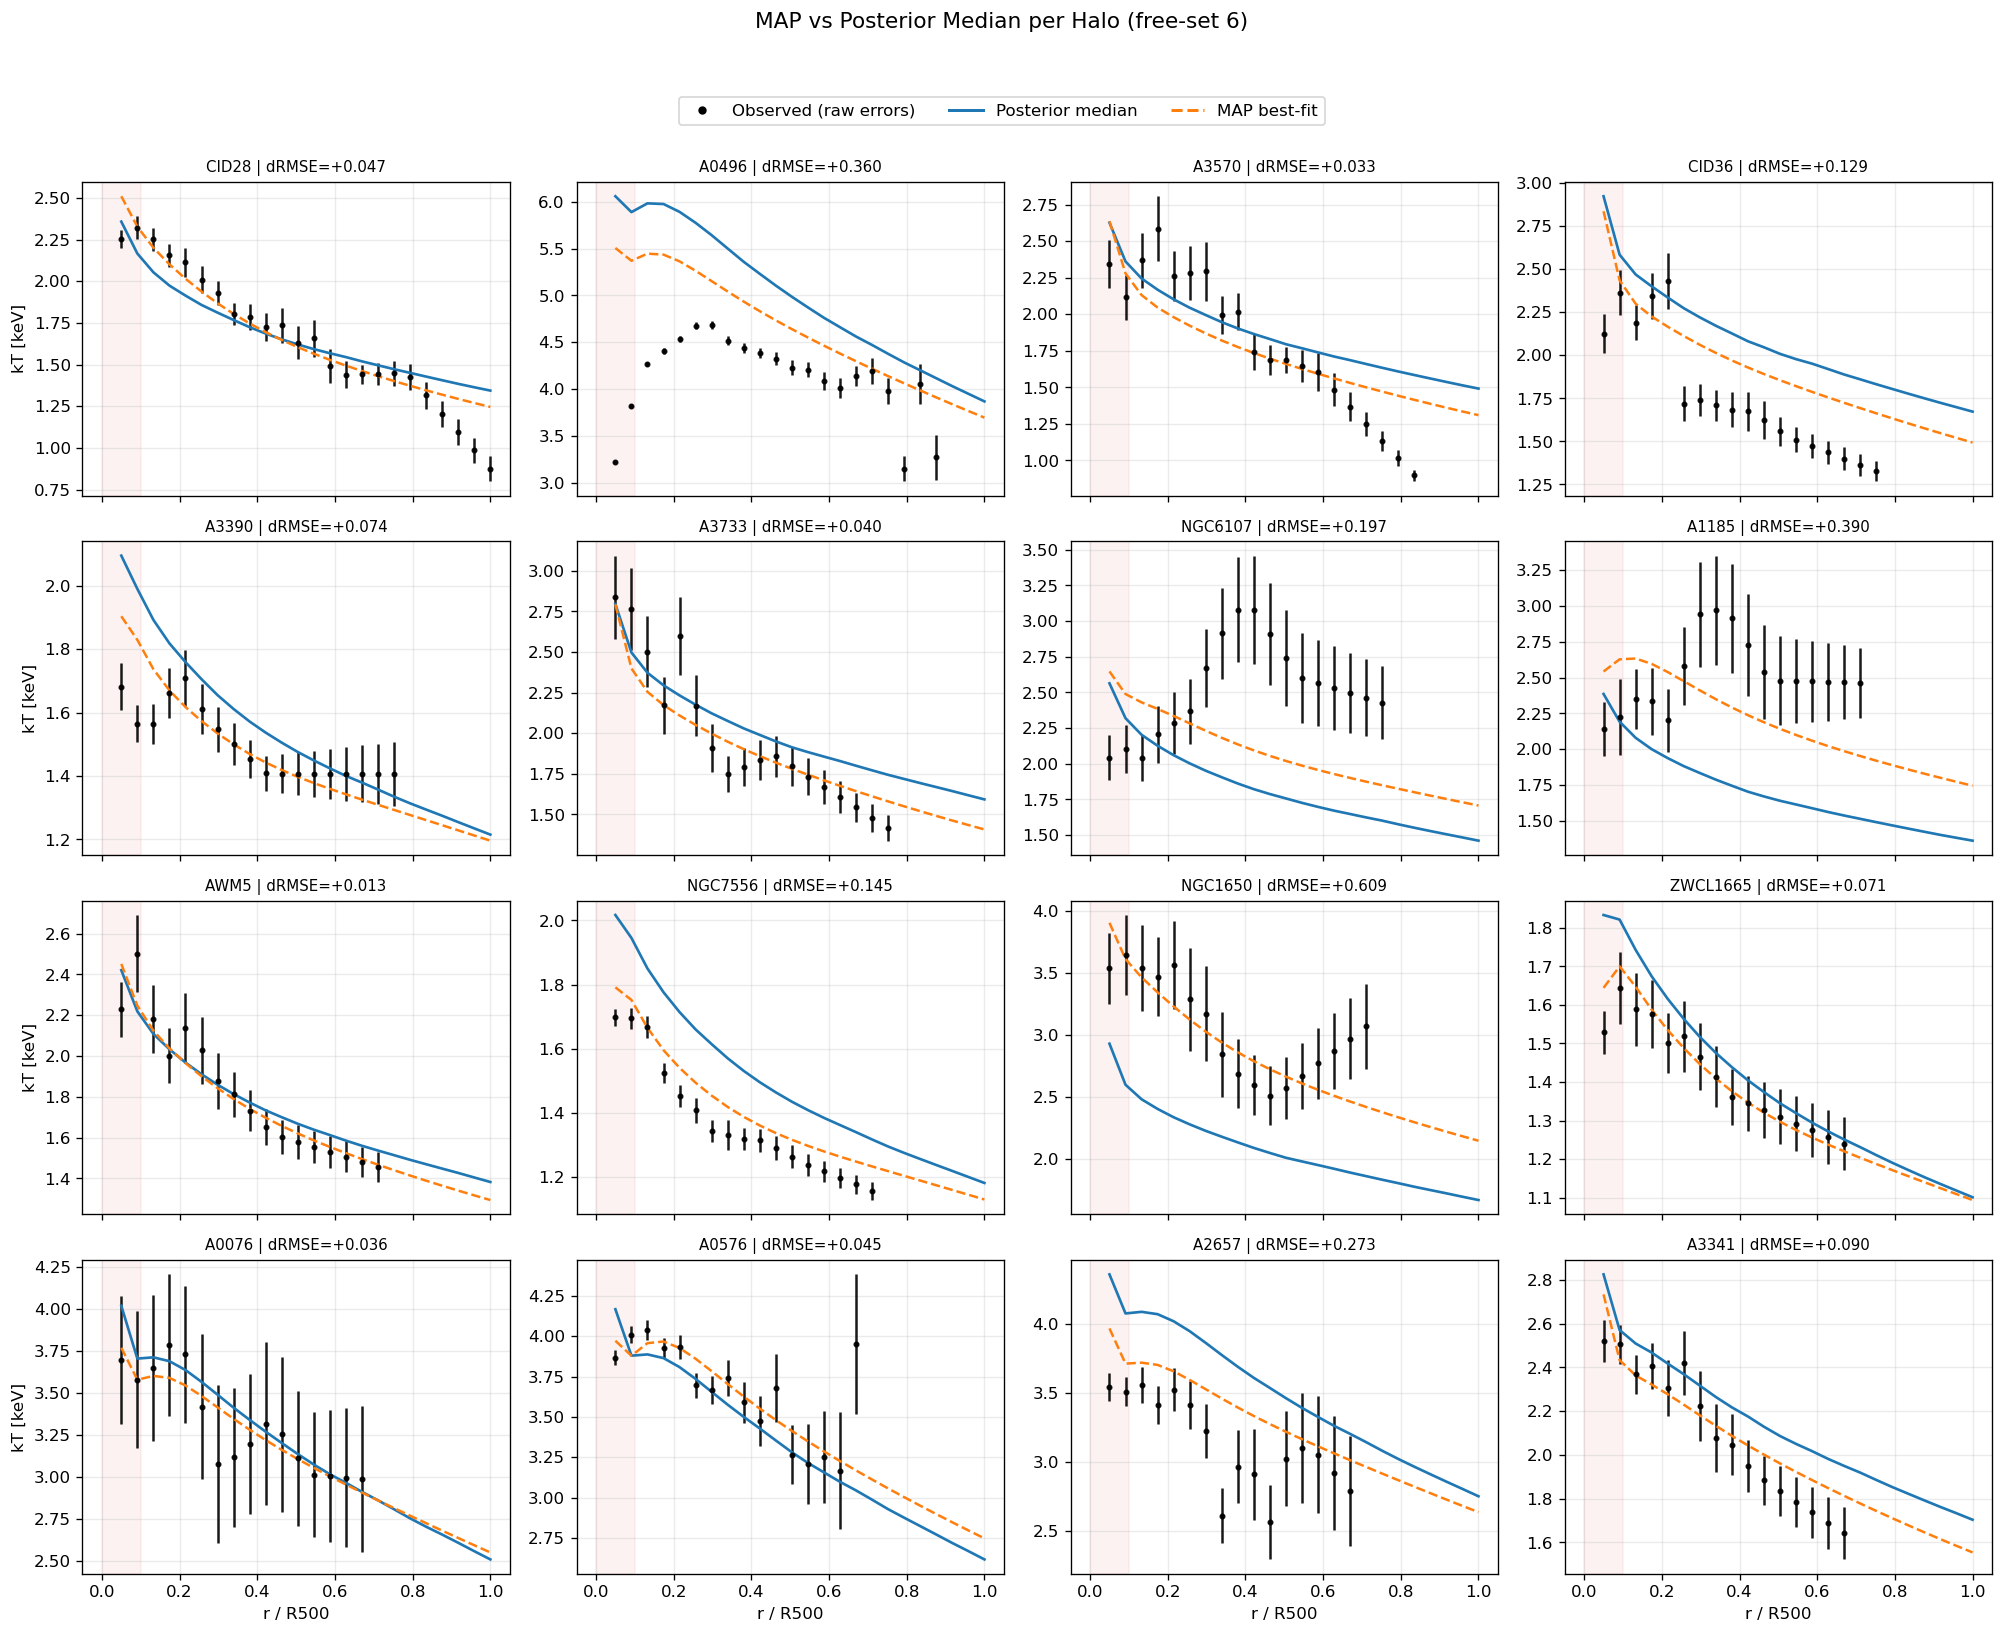

In [15]:
# MAP-vs-posterior diagnostic across halos (no MCMC in optimization)
import torch

FREE_SET_MAP = '6'
N_DRAW_POST_MAP = 40
MAX_HALOS_MAP = 16
MAP_STEPS = 180
MAP_LR = 0.08

if FREE_SET_MAP not in chains_by_key:
    raise KeyError(f'FREE_SET_MAP={FREE_SET_MAP} not in available keys {sorted(chains_by_key.keys())}')

npz_map = chains_by_key[FREE_SET_MAP]
samples_map = np.asarray(npz_map['samples'], dtype=float)
flat_map = samples_map.reshape(-1, samples_map.shape[-1])
batch_idxs_map = np.asarray(npz_map['batch_idxs'], dtype=int)
batch_names_map = [str(x) for x in npz_map['batch_names']]

theta_fid_map = np.asarray(npz_map['theta_fid'], dtype=float)
fit_idxs_map = np.asarray(npz_map['fit_idxs'], dtype=int)
prior_lo_map = np.asarray(npz_map['prior_lo_run'], dtype=float)
prior_hi_map = np.asarray(npz_map['prior_hi_run'], dtype=float)

# Posterior draws used to build posterior-median per halo
n_draw_post = min(N_DRAW_POST_MAP, flat_map.shape[0])
draw_idx_post = np.random.choice(flat_map.shape[0], size=n_draw_post, replace=False)
theta_draws_post = flat_map[draw_idx_post]

def _inv_sigmoid(x):
    x = np.clip(x, 1e-6, 1 - 1e-6)
    return np.log(x / (1 - x))

def optimize_map_for_halo(i_global):
    rr = obs.r_bins[i_global]
    halo_name = str(obs.names[i_global])
    M_h = obs.m500[i_global:i_global+1]
    r_h = obs.r_bins[i_global:i_global+1]

    y_raw, e_raw = load_raw_halo_profile_on_grid(halo_name, rr)
    if y_raw is None:
        return None

    valid = np.isfinite(y_raw) & np.isfinite(e_raw) & (y_raw > 0) & (e_raw > 0)
    if np.sum(valid) < 5:
        return None

    # Posterior median prediction curve for comparison
    post_profiles = []
    for th in theta_draws_post:
        pred = emu.predict(
            theta=th, M=M_h, r_bins=r_h, field=['temperature'],
            snapnum=90, redshift=0.0, n_samples=20,
        )
        post_profiles.append(pred.mean[0, :, 0])
    post_profiles = np.asarray(post_profiles)
    post_med = np.nanmedian(post_profiles, axis=0)

    # MAP-style optimization over free parameters using bounded transform
    theta0_fit = np.nanmedian(flat_map[:, fit_idxs_map], axis=0)
    lo = prior_lo_map[fit_idxs_map]
    hi = prior_hi_map[fit_idxs_map]
    span = np.clip(hi - lo, 1e-8, None)
    x0_unit = np.clip((theta0_fit - lo) / span, 1e-6, 1 - 1e-6)

    u = torch.tensor(_inv_sigmoid(x0_unit), dtype=torch.float32, device=emu.device, requires_grad=True)
    lo_t = torch.tensor(lo, dtype=torch.float32, device=emu.device)
    hi_t = torch.tensor(hi, dtype=torch.float32, device=emu.device)
    y_t = torch.tensor(y_raw, dtype=torch.float32, device=emu.device)
    e_t = torch.tensor(e_raw, dtype=torch.float32, device=emu.device)
    valid_t = torch.tensor(valid, dtype=torch.bool, device=emu.device)

    opt = torch.optim.Adam([u], lr=MAP_LR)
    best_loss = float('inf')
    best_theta = None

    for _ in range(MAP_STEPS):
        opt.zero_grad()
        x = torch.sigmoid(u)
        theta_fit_t = lo_t + x * (hi_t - lo_t)

        theta_full_t = torch.tensor(theta_fid_map, dtype=torch.float32, device=emu.device)
        theta_full_t[fit_idxs_map] = theta_fit_t

        mu_log10, _ = emu.predict_log10_differentiable(
            theta=theta_full_t, M=M_h, r_bins=r_h, field=['temperature'],
            snapnum=90, redshift=0.0, n_samples=1, deterministic=True,
        )
        pred_keV_t = torch.pow(torch.tensor(10.0, dtype=torch.float32, device=emu.device), mu_log10[0, :, 0])

        resid = (pred_keV_t[valid_t] - y_t[valid_t]) / torch.clamp(e_t[valid_t], min=1e-6)
        loss = torch.mean(resid ** 2)
        loss.backward()
        opt.step()

        lval = float(loss.detach().cpu())
        if lval < best_loss:
            best_loss = lval
            best_theta = theta_full_t.detach().cpu().numpy().astype(float)

    # Best-fit prediction curve
    pred_best = emu.predict(
        theta=best_theta, M=M_h, r_bins=r_h, field=['temperature'],
        snapnum=90, redshift=0.0, n_samples=20,
    )
    map_curve = pred_best.mean[0, :, 0]

    rmse_post = float(np.sqrt(np.mean((post_med[valid] - y_raw[valid]) ** 2)))
    rmse_map = float(np.sqrt(np.mean((map_curve[valid] - y_raw[valid]) ** 2)))
    core = valid & (rr < 0.1)
    core_rmse_post = float(np.sqrt(np.mean((post_med[core] - y_raw[core]) ** 2))) if np.any(core) else np.nan
    core_rmse_map = float(np.sqrt(np.mean((map_curve[core] - y_raw[core]) ** 2))) if np.any(core) else np.nan

    return {
        'halo_name': halo_name,
        'rr': rr,
        'y_raw': y_raw,
        'e_raw': e_raw,
        'valid': valid,
        'post_med': post_med,
        'map_curve': map_curve,
        'rmse_post': rmse_post,
        'rmse_map': rmse_map,
        'core_rmse_post': core_rmse_post,
        'core_rmse_map': core_rmse_map,
        'improvement_rmse': rmse_post - rmse_map,
        'M500_msun': float(obs.m500[i_global]),
    }

results_map = []
for i_local in range(min(MAX_HALOS_MAP, len(batch_idxs_map))):
    i_global = int(batch_idxs_map[i_local])
    out = optimize_map_for_halo(i_global)
    if out is not None:
        out['batch_local_index'] = i_local
        results_map.append(out)

if len(results_map) == 0:
    raise RuntimeError('No halos produced MAP results.')

map_df = pd.DataFrame([
    {
        'batch_local_index': r['batch_local_index'],
        'halo_name': r['halo_name'],
        'M500_msun': r['M500_msun'],
        'rmse_post': r['rmse_post'],
        'rmse_map': r['rmse_map'],
        'improvement_rmse': r['improvement_rmse'],
        'core_rmse_post': r['core_rmse_post'],
        'core_rmse_map': r['core_rmse_map'],
        'core_improvement_rmse': r['core_rmse_post'] - r['core_rmse_map'] if np.isfinite(r['core_rmse_post']) and np.isfinite(r['core_rmse_map']) else np.nan,
    }
    for r in results_map
])

print(f'MAP optimization completed for {len(map_df)} halos (free-set {FREE_SET_MAP}).')
print('Positive improvement means MAP fits better than posterior median.')
display(map_df.sort_values('improvement_rmse', ascending=False))

summary_map = pd.DataFrame({
    'metric': ['rmse_post_median', 'rmse_map_median', 'median_improvement', 'core_rmse_post_median', 'core_rmse_map_median', 'core_median_improvement'],
    'value': [
        float(np.nanmedian(map_df['rmse_post'])),
        float(np.nanmedian(map_df['rmse_map'])),
        float(np.nanmedian(map_df['improvement_rmse'])),
        float(np.nanmedian(map_df['core_rmse_post'])),
        float(np.nanmedian(map_df['core_rmse_map'])),
        float(np.nanmedian(map_df['core_improvement_rmse'])),
    ]
})
display(summary_map)

# 16-panel comparison: posterior median vs MAP best-fit
n_pan = len(results_map)
n_cols = 4
n_rows = int(np.ceil(n_pan / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows), sharex=True)
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for p, r in enumerate(results_map):
    rr = r['rr']
    y = r['y_raw']
    e = r['e_raw']
    v = r['valid']
    post_med = r['post_med']
    map_curve = r['map_curve']

    ax = axes[p // n_cols, p % n_cols]
    ax.axvspan(0.0, 0.1, color='tab:red', alpha=0.06)
    ax.errorbar(rr[v], y[v], yerr=e[v], fmt='o', ms=2.6, color='black', alpha=0.9)
    ax.plot(rr, post_med, lw=1.6, color='tab:blue', label='Posterior median')
    ax.plot(rr, map_curve, lw=1.5, color='tab:orange', ls='--', label='MAP best-fit')
    ax.set_title(f"{r['halo_name']} | dRMSE={r['improvement_rmse']:+.3f}", fontsize=9)
    ax.grid(alpha=0.25)

    if (p // n_cols) == n_rows - 1:
        ax.set_xlabel('r / R500')
    if (p % n_cols) == 0:
        ax.set_ylabel('kT [keV]')

for p in range(n_pan, n_rows * n_cols):
    axes[p // n_cols, p % n_cols].axis('off')

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=4, label='Observed (raw errors)'),
    plt.Line2D([0], [0], color='tab:blue', lw=1.8, label='Posterior median'),
    plt.Line2D([0], [0], color='tab:orange', lw=1.8, ls='--', label='MAP best-fit'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.01))
plt.suptitle(f'MAP vs Posterior Median per Halo (free-set {FREE_SET_MAP})', y=1.06, fontsize=13)
plt.tight_layout()
plt.show()

## Training vs Inference Alignment Diagnostics

This section checks whether we are comparing apples-to-apples:
- training target/channels and preprocessing args,
- training vs observed mass/radius domain coverage,
- mass convention audit (catalog radius definition and R500 -> M500 conversion path),
- radial-bin consistency between training profiles, chain sampling, and current evaluation grid,
- how far inference inputs are from training normalization center (z-score in emulator input space).

Training args snapshot (from checkpoint):


,key,value
0,profiles_base,/mnt/home/mlee1/ceph/Profiles_cy
1,suite,IllustrisTNG
2,sim_set,SB35
3,target_name,all_profiles
4,all_profile_targets,"['gas_density', 'temperature', 'pressure', 'me..."
5,snap_for_scan,90
6,radial_stride,1
7,r500_physical_factor,1.0
8,mass_floor,0.0
9,min_valid_frac,0.5


,check,result,evidence
0,catalog header contains R500_amin,True,# Name RA DEC redshift NH(1E20) MCXC_flux(1E-1...
1,catalog header contains R200,False,# Name RA DEC redshift NH(1E20) MCXC_flux(1E-1...
2,loader uses r500_arcmin field,True,run_nuts_temperature.load_temperature_profiles
3,loader derives m500 from r500,True,run_nuts_temperature.load_temperature_profiles


Mass audit interpretation: current pipeline treats catalog radius as R500 and derives M500 from that R500(z).
If the upstream catalog semantics were actually R200 despite the header, then inferred masses would be systematically mis-scaled.
Discovered 1012 runs; scanning first 200 runs for domain statistics...


,quantity,train_minmax,train_p01_p99,obs_batch_minmax,frac_obs_batch_outside_train_minmax,frac_obs_batch_outside_train_p01_p99
0,log10(M500),"[11.912, 14.917]","[12.272, 13.992]","[13.690, 14.622]",0.0,0.3125
1,log10(r/R500),"[-2.006, 1.605]","[-1.405, 1.410]","[-1.301, 0.000]",0.0,0.0000


Training n_r values seen in scan: [30]
Chain sampling n_r: 24
Current notebook evaluation n_r: 30
NOTE: Evaluation grid differs from sampling grid. Metrics here are posterior re-evaluations on the current grid.


,feature,median_abs_z,frac_abs_z_gt_2,frac_abs_z_gt_3
0,log10(M500),3.290924,1.0,0.8125
1,log10(r/R500),0.384998,0.0,0.0000


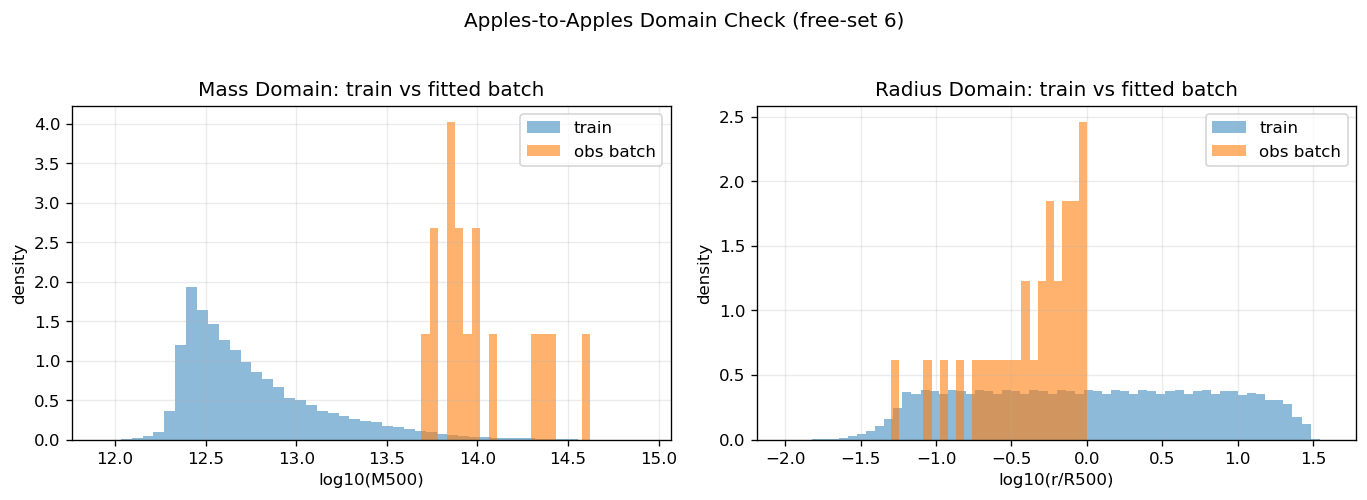

In [21]:
# Apples-to-apples diagnostic: training domain vs inference domain
import inspect
import run_nuts_temperature as rnt
from train_anp_emulator import discover_runs, resolve_profile_file, select_target

MAX_TRAIN_RUNS_SCAN = 200
FREE_SET_DOMAIN = FREE_SET_MAP if 'FREE_SET_MAP' in globals() else ('6' if '6' in chains_by_key else sorted(chains_by_key.keys())[0])

if FREE_SET_DOMAIN not in chains_by_key:
    raise KeyError(f'FREE_SET_DOMAIN={FREE_SET_DOMAIN} not in available keys {sorted(chains_by_key.keys())}')

npz_domain = chains_by_key[FREE_SET_DOMAIN]
batch_idxs_domain = np.asarray(npz_domain['batch_idxs'], dtype=int)

train_args = dict(getattr(emu, 'args', {}))
snapnums = list(train_args.get('resolved_snapnums', [train_args.get('snapnum', 90)]))
if len(snapnums) == 0:
    snapnums = [90]
snap_for_scan = int(snapnums[0])

profiles_base = Path(str(train_args.get('profiles_base', '/mnt/home/mlee1/ceph/Profiles_cy')))
suite = str(train_args.get('suite', 'IllustrisTNG'))
sim_set = str(train_args.get('sim_set', 'SB35'))
target_name = str(train_args.get('target_name', 'all_profiles'))
all_profile_targets = train_args.get('resolved_all_profile_targets', train_args.get('all_profiles_subset', None))
eps = float(train_args.get('eps', 1e-30))
log_channel_floor = float(train_args.get('log_channel_floor', 0.0))
radial_stride = int(train_args.get('radial_stride', 1))
r500_factor = float(train_args.get('r500_physical_factor', 1.0))
mass_floor = float(train_args.get('mass_floor', 0.0))
min_valid_frac = float(train_args.get('min_valid_frac', 0.5))

print('Training args snapshot (from checkpoint):')
display(pd.DataFrame({
    'key': [
        'profiles_base', 'suite', 'sim_set', 'target_name',
        'all_profile_targets', 'snap_for_scan', 'radial_stride',
        'r500_physical_factor', 'mass_floor', 'min_valid_frac',
    ],
    'value': [
        str(profiles_base), suite, sim_set, target_name, str(all_profile_targets),
        snap_for_scan, radial_stride, r500_factor, mass_floor, min_valid_frac,
    ]
}))

# Mass-definition audit from catalog header plus run script source.
catalog_header_line = ''
try:
    with open(catalog_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            s = line.strip()
            if s.startswith('#'):
                catalog_header_line = s
                break
            if s:
                break
except Exception as exc:
    print(f'Could not read catalog header for mass audit: {exc}')

header_upper = catalog_header_line.upper()
load_src = inspect.getsource(rnt.load_temperature_profiles)

mass_audit = pd.DataFrame([
    {
        'check': 'catalog header contains R500_amin',
        'result': bool('R500_AMIN' in header_upper),
        'evidence': catalog_header_line if catalog_header_line else 'header unavailable',
    },
    {
        'check': 'catalog header contains R200',
        'result': bool('R200' in header_upper),
        'evidence': catalog_header_line if catalog_header_line else 'header unavailable',
    },
    {
        'check': 'loader uses r500_arcmin field',
        'result': bool('r500_arcmin' in load_src),
        'evidence': 'run_nuts_temperature.load_temperature_profiles',
    },
    {
        'check': 'loader derives m500 from r500',
        'result': bool('m500_from_r500' in load_src),
        'evidence': 'run_nuts_temperature.load_temperature_profiles',
    },
])

display(mass_audit)
print('Mass audit interpretation: current pipeline treats catalog radius as R500 and derives M500 from that R500(z).')
print('If the upstream catalog semantics were actually R200 despite the header, then inferred masses would be systematically mis-scaled.')

runs_all = discover_runs(profiles_base, suite=suite, sim_set=sim_set, snapnum=snap_for_scan)
if len(runs_all) == 0:
    raise RuntimeError(f'No training runs discovered in {profiles_base} for {suite}/{sim_set} snap={snap_for_scan}')

runs_scan = runs_all[: min(MAX_TRAIN_RUNS_SCAN, len(runs_all))]
print(f'Discovered {len(runs_all)} runs; scanning first {len(runs_scan)} runs for domain statistics...')

mu_e = 2.0 / (1.0 + 0.76)
mp = 1.67e-24

train_logM_list = []
train_logR_list = []
train_n_r_list = []
loaded_runs = 0

for run in runs_scan:
    try:
        fp = resolve_profile_file(run, base_path=profiles_base, suite=suite, sim_set=sim_set, snapnum=snap_for_scan)
        with np.load(fp) as data:
            m500c = data['M500c'].astype(np.float32)
            r500c = data['R500c'].astype(np.float32)
            r = data['radial_bins'].astype(np.float32)
            y, valid_mask = select_target(
                data,
                target_name=target_name,
                mu_e=mu_e,
                mp=mp,
                eps=eps,
                all_profile_targets=all_profile_targets,
                log_channel_floor=log_channel_floor,
            )

        if y.ndim == 2:
            y = y[..., None]
            valid_mask = valid_mask[..., None]

        if radial_stride > 1:
            r = r[::radial_stride]
            y = y[:, ::radial_stride, :]
            valid_mask = valid_mask[:, ::radial_stride, :]

        keep = np.ones(m500c.shape[0], dtype=bool)
        if mass_floor > 0.0:
            keep &= (np.log10(np.clip(m500c, 1e10, None)) >= mass_floor)

        if min_valid_frac > 0.0:
            per_halo_valid = valid_mask.reshape(valid_mask.shape[0], -1).mean(axis=1)
            keep &= (per_halo_valid >= min_valid_frac)

        if np.sum(keep) == 0:
            continue

        m_keep = m500c[keep]
        r500_keep = r500c[keep]

        logM = np.log10(np.clip(m_keep, 1e10, None))
        r_over_r500 = r[None, :] / np.clip(r500_keep[:, None] * r500_factor, 1e-12, None)
        logR = np.log10(np.clip(r_over_r500, 1e-4, None))

        train_logM_list.append(logM.reshape(-1))
        train_logR_list.append(logR.reshape(-1))
        train_n_r_list.append(int(r.shape[0]))
        loaded_runs += 1
    except Exception:
        continue

if loaded_runs == 0:
    raise RuntimeError('No training runs loaded successfully for domain check.')

train_logM = np.concatenate(train_logM_list)
train_logR = np.concatenate(train_logR_list)

# Observed domains
obs_logM_all = np.log10(np.clip(obs.m500, 1e10, None))
obs_logR_all = np.log10(np.clip(obs.r_bins, 1e-4, None)).reshape(-1)
obs_logM_batch = np.log10(np.clip(obs.m500[batch_idxs_domain], 1e10, None))
obs_logR_batch = np.log10(np.clip(obs.r_bins[batch_idxs_domain], 1e-4, None)).reshape(-1)

def _range_stats(x):
    return {
        'min': float(np.nanmin(x)),
        'p01': float(np.nanpercentile(x, 1)),
        'p50': float(np.nanpercentile(x, 50)),
        'p99': float(np.nanpercentile(x, 99)),
        'max': float(np.nanmax(x)),
    }

train_M_stats = _range_stats(train_logM)
train_R_stats = _range_stats(train_logR)
obsM_stats = _range_stats(obs_logM_batch)
obsR_stats = _range_stats(obs_logR_batch)

def _frac_outside(x, lo, hi):
    return float(np.mean((x < lo) | (x > hi)))

domain_table = pd.DataFrame([
    {
        'quantity': 'log10(M500)',
        'train_minmax': f"[{train_M_stats['min']:.3f}, {train_M_stats['max']:.3f}]",
        'train_p01_p99': f"[{train_M_stats['p01']:.3f}, {train_M_stats['p99']:.3f}]",
        'obs_batch_minmax': f"[{obsM_stats['min']:.3f}, {obsM_stats['max']:.3f}]",
        'frac_obs_batch_outside_train_minmax': _frac_outside(obs_logM_batch, train_M_stats['min'], train_M_stats['max']),
        'frac_obs_batch_outside_train_p01_p99': _frac_outside(obs_logM_batch, train_M_stats['p01'], train_M_stats['p99']),
    },
    {
        'quantity': 'log10(r/R500)',
        'train_minmax': f"[{train_R_stats['min']:.3f}, {train_R_stats['max']:.3f}]",
        'train_p01_p99': f"[{train_R_stats['p01']:.3f}, {train_R_stats['p99']:.3f}]",
        'obs_batch_minmax': f"[{obsR_stats['min']:.3f}, {obsR_stats['max']:.3f}]",
        'frac_obs_batch_outside_train_minmax': _frac_outside(obs_logR_batch, train_R_stats['min'], train_R_stats['max']),
        'frac_obs_batch_outside_train_p01_p99': _frac_outside(obs_logR_batch, train_R_stats['p01'], train_R_stats['p99']),
    },
])
display(domain_table)

# Radial-bin consistency check
n_r_train_unique = sorted(set(train_n_r_list))
n_r_obs = int(obs.r_bins.shape[1])
n_r_chain = int(globals().get('RR500_NBIN_CHAIN', n_r_obs))
n_r_eval = int(globals().get('RR500_NBIN_EVAL', n_r_obs))

print(f'Training n_r values seen in scan: {n_r_train_unique}')
print(f'Chain sampling n_r: {n_r_chain}')
print(f'Current notebook evaluation n_r: {n_r_eval}')

if n_r_eval != n_r_chain:
    print('NOTE: Evaluation grid differs from sampling grid. Metrics here are posterior re-evaluations on the current grid.')

# z-score coverage in emulator normalized feature space
x_mean_np = emu.x_mean.detach().cpu().numpy()
x_std_np = emu.x_std.detach().cpu().numpy()
zM_batch = (obs_logM_batch - x_mean_np[0]) / np.clip(x_std_np[0], 1e-8, None)
zR_batch = (obs_logR_batch - x_mean_np[1]) / np.clip(x_std_np[1], 1e-8, None)

z_table = pd.DataFrame([
    {'feature': 'log10(M500)', 'median_abs_z': float(np.median(np.abs(zM_batch))), 'frac_abs_z_gt_2': float(np.mean(np.abs(zM_batch) > 2)), 'frac_abs_z_gt_3': float(np.mean(np.abs(zM_batch) > 3))},
    {'feature': 'log10(r/R500)', 'median_abs_z': float(np.median(np.abs(zR_batch))), 'frac_abs_z_gt_2': float(np.mean(np.abs(zR_batch) > 2)), 'frac_abs_z_gt_3': float(np.mean(np.abs(zR_batch) > 3))},
])
display(z_table)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].hist(train_logM, bins=50, alpha=0.5, density=True, label='train')
axes[0].hist(obs_logM_batch, bins=20, alpha=0.6, density=True, label='obs batch')
axes[0].set_xlabel('log10(M500)')
axes[0].set_ylabel('density')
axes[0].set_title('Mass Domain: train vs fitted batch')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].hist(train_logR, bins=60, alpha=0.5, density=True, label='train')
axes[1].hist(obs_logR_batch, bins=24, alpha=0.6, density=True, label='obs batch')
axes[1].set_xlabel('log10(r/R500)')
axes[1].set_ylabel('density')
axes[1].set_title('Radius Domain: train vs fitted batch')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.suptitle(f'Apples-to-Apples Domain Check (free-set {FREE_SET_DOMAIN})', y=1.03)
plt.tight_layout()
plt.show()

In [22]:
# Compact status summary for model triage
import numpy as np
import pandas as pd

print('--- GRID CHECK ---')
print('RR500_NBIN_CHAIN:', globals().get('RR500_NBIN_CHAIN', None))
print('RR500_NBIN_TRAIN:', globals().get('RR500_NBIN_TRAIN', None))
print('RR500_NBIN_EVAL :', globals().get('RR500_NBIN_EVAL', None))

print('\n--- DOMAIN SHIFT ---')
if 'domain_table' in globals():
    display(domain_table)
if 'z_table' in globals():
    display(z_table)

print('\n--- MAP VS POSTERIOR ---')
if 'summary_map' in globals():
    display(summary_map)
if 'map_df' in globals():
    print('n_halos_map:', len(map_df))
    if 'improvement_rmse' in map_df.columns:
        print('median improvement rmse:', float(np.nanmedian(map_df['improvement_rmse'])))
        print('frac halos MAP better:', float(np.mean(map_df['improvement_rmse'] > 0)))

print('\n--- POPULATION PPC ---')
if 'summary' in globals():
    display(summary)
if 'pop_df' in globals() and len(pop_df) > 0:
    print('n_halos_pop:', len(pop_df))
    if 'rmse_keV' in pop_df.columns:
        print('median rmse_keV:', float(np.nanmedian(pop_df['rmse_keV'])))
    if 'core_rmse_keV' in pop_df.columns:
        print('median core_rmse_keV:', float(np.nanmedian(pop_df['core_rmse_keV'])))


--- GRID CHECK ---
RR500_NBIN_CHAIN: 24
RR500_NBIN_TRAIN: 30
RR500_NBIN_EVAL : 30

--- DOMAIN SHIFT ---


,quantity,train_minmax,train_p01_p99,obs_batch_minmax,frac_obs_batch_outside_train_minmax,frac_obs_batch_outside_train_p01_p99
0,log10(M500),"[11.912, 14.917]","[12.272, 13.992]","[13.690, 14.622]",0.0,0.3125
1,log10(r/R500),"[-2.006, 1.605]","[-1.405, 1.410]","[-1.301, 0.000]",0.0,0.0000


,feature,median_abs_z,frac_abs_z_gt_2,frac_abs_z_gt_3
0,log10(M500),3.290924,1.0,0.8125
1,log10(r/R500),0.384998,0.0,0.0000



--- MAP VS POSTERIOR ---


,metric,value
0,rmse_post_median,0.241700
1,rmse_map_median,0.199381
2,median_improvement,0.081912
3,core_rmse_post_median,0.256852
4,core_rmse_map_median,0.242472
5,core_median_improvement,0.096569


n_halos_map: 16
median improvement rmse: 0.08191204802766275
frac halos MAP better: 1.0

--- POPULATION PPC ---


,metric,median,p16,p84
0,rmse_keV,0.242864,0.174401,0.801875
1,coverage68,0.029412,0.000000,0.125000
2,chi2_red_raw_errors,7.363958,3.406445,32.107329
3,core_rmse_keV,0.256768,0.205302,0.669184
4,core_coverage68,0.000000,0.000000,0.000000


n_halos_pop: 16
median rmse_keV: 0.2428635927502239
median core_rmse_keV: 0.2567682397365178
